## Imports

In [29]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

## Settings

In [30]:
# ---------------------------------------------------
# Settings
# ---------------------------------------------------
EMB_DIR = Path("/proj/berzelius-2025-315/users/x_dilwi/SSL_method/results/mae_local_run1_lr0.001_epochs500/selected_embeddings")

wanted = [
    "epochepoch=0099-v1",
    "epochepoch=0199-v1",
    "epochepoch=0299-v1",
    "epochepoch=0399",
    "epochepoch=0499",
]

SAVE_DIR = EMB_DIR / "plots_compare_all_levels"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

## Helper functions

In [31]:
# ---------------------------------------------------
# Helpers: metadata + loading
# ---------------------------------------------------
def epoch_sort_key(name: str):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 10**9


def safe_str(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)


def parse_name_metadata(name: str):
    s = safe_str(name)

    core_match = re.search(r"(Core\[[^\]]+\])", s)
    core_only = core_match.group(1) if core_match else None

    patient_match = re.match(r"(.+?)_Core\[[^\]]+\]", s)
    parsed_group_id = patient_match.group(1) if patient_match else None

    coord_match = re.search(r"_\[(\d+),(\d+)\]", s)
    if coord_match:
        x = int(coord_match.group(1))
        y = int(coord_match.group(2))
    else:
        x, y = None, None

    image_match = re.search(
        r"(BOMI2_TIL_\d+_Core\[[^\]]+\]_\[\d+,\d+\].*?\.tif)", s
    )
    image_name = image_match.group(1) if image_match else None

    return {
        "raw_name": s,
        "parsed_group_id": parsed_group_id if parsed_group_id is not None else s,
        "core_only": core_only,
        "x": x,
        "y": y,
        "image_name": image_name,
    }

def load_embeddings(emb_dir: Path, wanted_list):
    data = {}
    for stem in wanted_list:
        emb_path = emb_dir / f"embeddings_{stem}.npy"
        name_path = emb_dir / f"names_{stem}.npy"

        if not emb_path.exists():
            print(f"Missing: {emb_path}")
            continue

        emb = np.load(emb_path, allow_pickle=True)
        names = np.load(name_path, allow_pickle=True) if name_path.exists() else None

        emb = normalize(emb)

        rows = []
        if names is not None:
            for i, n in enumerate(names):
                meta = parse_name_metadata(n)
                meta["idx"] = i
                rows.append(meta)
            meta_df = pd.DataFrame(rows)
        else:
            meta_df = pd.DataFrame({
                "idx": np.arange(len(emb)),
                "raw_name": [f"sample_{i}" for i in range(len(emb))],
                "parsed_group_id": [f"group_{i}" for i in range(len(emb))],
                "core_only": [None] * len(emb),
                "x": [None] * len(emb),
                "y": [None] * len(emb),
                "image_name": [None] * len(emb),
            })

        data[stem] = {
            "emb": emb,
            "names": names,
            "meta": meta_df,
        }

        print(f"Loaded {stem}: {emb.shape}")
        if "image_name" in meta_df.columns:
            print("  matched image_name candidates:", meta_df["image_name"].notna().sum())

    return dict(sorted(data.items(), key=lambda x: epoch_sort_key(x[0])))


def merge_clinical_metadata_into_data(data, clinical_df):
    merged_data = {}

    for ckpt, item in data.items():
        meta = item["meta"].copy()

        merged_meta = meta.merge(
            clinical_df,
            on="image_name",
            how="left"
        )

        merged_data[ckpt] = {
            "emb": item["emb"],
            "names": item["names"],
            "meta": merged_meta,
        }

        print(f"\n{ckpt}")
        print("  meta shape:", merged_meta.shape)
        print("  rows with matched patient_id:", merged_meta['patient_id'].notna().sum())
        print("  unique real patients:", merged_meta['patient_id'].nunique())

    return merged_data

def pretty_ckpt_name(name: str):
    mapping = {
        "epochepoch=0099-v1": "Epoch 100",
        "epochepoch=0199-v1": "Epoch 200",
        "epochepoch=0299-v1": "Epoch 300",
        "epochepoch=0399": "Epoch 400",
        "epochepoch=0499": "Epoch 500",
    }
    return mapping.get(name, name)

In [32]:
# ---------------------------------------------------
# Helpers: PCA / UMAP
# ---------------------------------------------------
def fit_shared_pca(all_embs, n_components=2):
    pca = PCA(n_components=n_components, random_state=42)
    all_2d = pca.fit_transform(all_embs)
    return pca, all_2d


def fit_shared_umap(all_embs, n_components=2):
    if not HAS_UMAP:
        return None, None
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42,
        transform_seed=42,
    )
    all_2d = reducer.fit_transform(all_embs)
    return reducer, all_2d

In [33]:
# ---------------------------------------------------
# Helpers: plotting
# ---------------------------------------------------
def compute_global_limits(coords_dict, pad_ratio=0.05):
    xs = np.concatenate([v[:, 0] for v in coords_dict.values()])
    ys = np.concatenate([v[:, 1] for v in coords_dict.values()])

    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()

    xpad = (xmax - xmin) * pad_ratio if xmax > xmin else 1.0
    ypad = (ymax - ymin) * pad_ratio if ymax > ymin else 1.0

    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)


def plot_grid(coords_dict, title, save_path=None, xlabel="Dim 1", ylabel="Dim 2", point_size=2, alpha=0.35):
    n = len(coords_dict)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    xlim, ylim = compute_global_limits(coords_dict)

    for ax, (name, coords) in zip(axes, coords_dict.items()):
        ax.scatter(coords[:, 0], coords[:, 1], s=point_size, alpha=alpha)
        ax.set_title(f"{pretty_ckpt_name(name)}\nN={len(coords)}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.2)

    for ax in axes[len(coords_dict):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_overlay(coords_dict, title, save_path=None, xlabel="Dim 1", ylabel="Dim 2", point_size=2, alpha=0.20):
    plt.figure(figsize=(9, 7))
    for name, coords in coords_dict.items():
        plt.scatter(coords[:, 0], coords[:, 1], s=point_size, alpha=alpha, label=pretty_ckpt_name(name))

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.2)
    plt.legend(markerscale=4)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_colored_subset(meta_out, color_col, title, save_path=None, max_groups=20, s=3, alpha=0.5):
    plt.figure(figsize=(9, 7))

    groups = meta_out[color_col].value_counts().index.tolist()[:max_groups]
    sub = meta_out[meta_out[color_col].isin(groups)].copy()

    for g, gdf in sub.groupby(color_col):
        plt.scatter(gdf["x2d"], gdf["y2d"], s=s, alpha=alpha, label=str(g))

    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True, alpha=0.2)
    plt.legend(markerscale=4, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_grid_independent_axes(
    coords_dict,
    title,
    xlabel="Dim 1",
    ylabel="Dim 2",
    point_size=2,
    alpha=0.35,
    ncols=3,
):
    """
    Each subplot has its own axis limits (autoscale).
    Useful when you want to see each checkpoint's internal shape more clearly.
    """
    n = len(coords_dict)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (name, coords) in zip(axes, coords_dict.items()):
        ax.scatter(coords[:, 0], coords[:, 1], s=point_size, alpha=alpha)
        ax.set_title(f"{name}\nN={len(coords)}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.2)
        # NOTE: no shared xlim/ylim here -> each subplot autoscale

    for ax in axes[len(coords_dict):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()

In [34]:
# ---------------------------------------------------
# Helpers: aggregation + shared projection
# ---------------------------------------------------

def aggregate_embeddings(emb, meta_df, group_col):
    valid = meta_df[group_col].notna()
    meta_df = meta_df.loc[valid].copy()

    groups = []
    rows = []

    for group_name, sub_df in meta_df.groupby(group_col):
        idx = sub_df["idx"].values
        vec = emb[idx].mean(axis=0)
        groups.append(vec)

        row = sub_df.iloc[0].copy()
        row[group_col] = group_name
        rows.append(row)

    groups = np.stack(groups, axis=0)
    groups = normalize(groups)

    agg_df = pd.DataFrame(rows).reset_index(drop=True)
    return groups, agg_df


def project_and_split_shared(data_dict, level="patch", method="pca"):
    """
    level = patch / core / patient
    method = pca / umap
    """
    mats = []
    lengths = []
    names_order = list(data_dict.keys())

    per_ckpt_meta = {}

    for ckpt, item in data_dict.items():
        emb = item["emb"]
        meta = item["meta"]

        if level == "patch":
            mat = emb
            out_meta = meta.copy()

        elif level == "core":
            mat, out_meta = aggregate_embeddings(emb, meta, "image_name")

        elif level == "patient":
            mat, out_meta = aggregate_embeddings(emb, meta, "patient_id")

        else:
            raise ValueError(f"Unknown level: {level}")

        mats.append(mat)
        lengths.append(len(mat))
        per_ckpt_meta[ckpt] = out_meta

    all_mat = np.concatenate(mats, axis=0)

    if method == "pca":
        model, all_2d = fit_shared_pca(all_mat, n_components=2)
    elif method == "umap":
        if not HAS_UMAP:
            return None, None, None
        model, all_2d = fit_shared_umap(all_mat, n_components=2)
    else:
        raise ValueError(f"Unknown method: {method}")

    coords_dict = {}
    meta_out = {}
    start = 0
    for ckpt, length in zip(names_order, lengths):
        coords = all_2d[start:start + length]
        df = per_ckpt_meta[ckpt].copy()
        df["x2d"] = coords[:, 0]
        df["y2d"] = coords[:, 1]

        coords_dict[ckpt] = coords
        meta_out[ckpt] = df
        start += length

    return model, coords_dict, meta_out

## Load Data

In [35]:
# ---------------------------------------------------
# Load embeddings
# ---------------------------------------------------

data = load_embeddings(EMB_DIR, wanted)

if len(data) == 0:
    raise ValueError("No embeddings found.")

clinical_df = pd.read_csv("/proj/berzelius-2025-315/users/x_dilwi/bomi2_image_level_with_survival.csv")
print(clinical_df.columns.tolist())
clinical_df.head()
data = merge_clinical_metadata_into_data(data, clinical_df)


Loaded epochepoch=0099-v1: (89430, 768)
  matched image_name candidates: 89430
Loaded epochepoch=0199-v1: (89430, 768)
  matched image_name candidates: 89430
Loaded epochepoch=0299-v1: (89430, 768)
  matched image_name candidates: 89430
Loaded epochepoch=0399: (89430, 768)
  matched image_name candidates: 89430
Loaded epochepoch=0499: (89430, 768)
  matched image_name candidates: 89430
['image_path', 'image_name', 'sample_name', 'row', 'col', 'patient_id_raw', 'patient_id', 'region_area_mm2', 'sample_region', 'cohort', 'Histology', 'Age', 'Sex', 'Smoking', 'Stage (7th ed.)', 'Performance status (WHO)', 'Follow-up (days)', 'Dead/Alive', 'time', 'event']

epochepoch=0099-v1
  meta shape: (89430, 26)
  rows with matched patient_id: 89430
  unique real patients: 298

epochepoch=0199-v1
  meta shape: (89430, 26)
  rows with matched patient_id: 89430
  unique real patients: 298

epochepoch=0299-v1
  meta shape: (89430, 26)
  rows with matched patient_id: 89430
  unique real patients: 298

ep

## Patch-level PCA

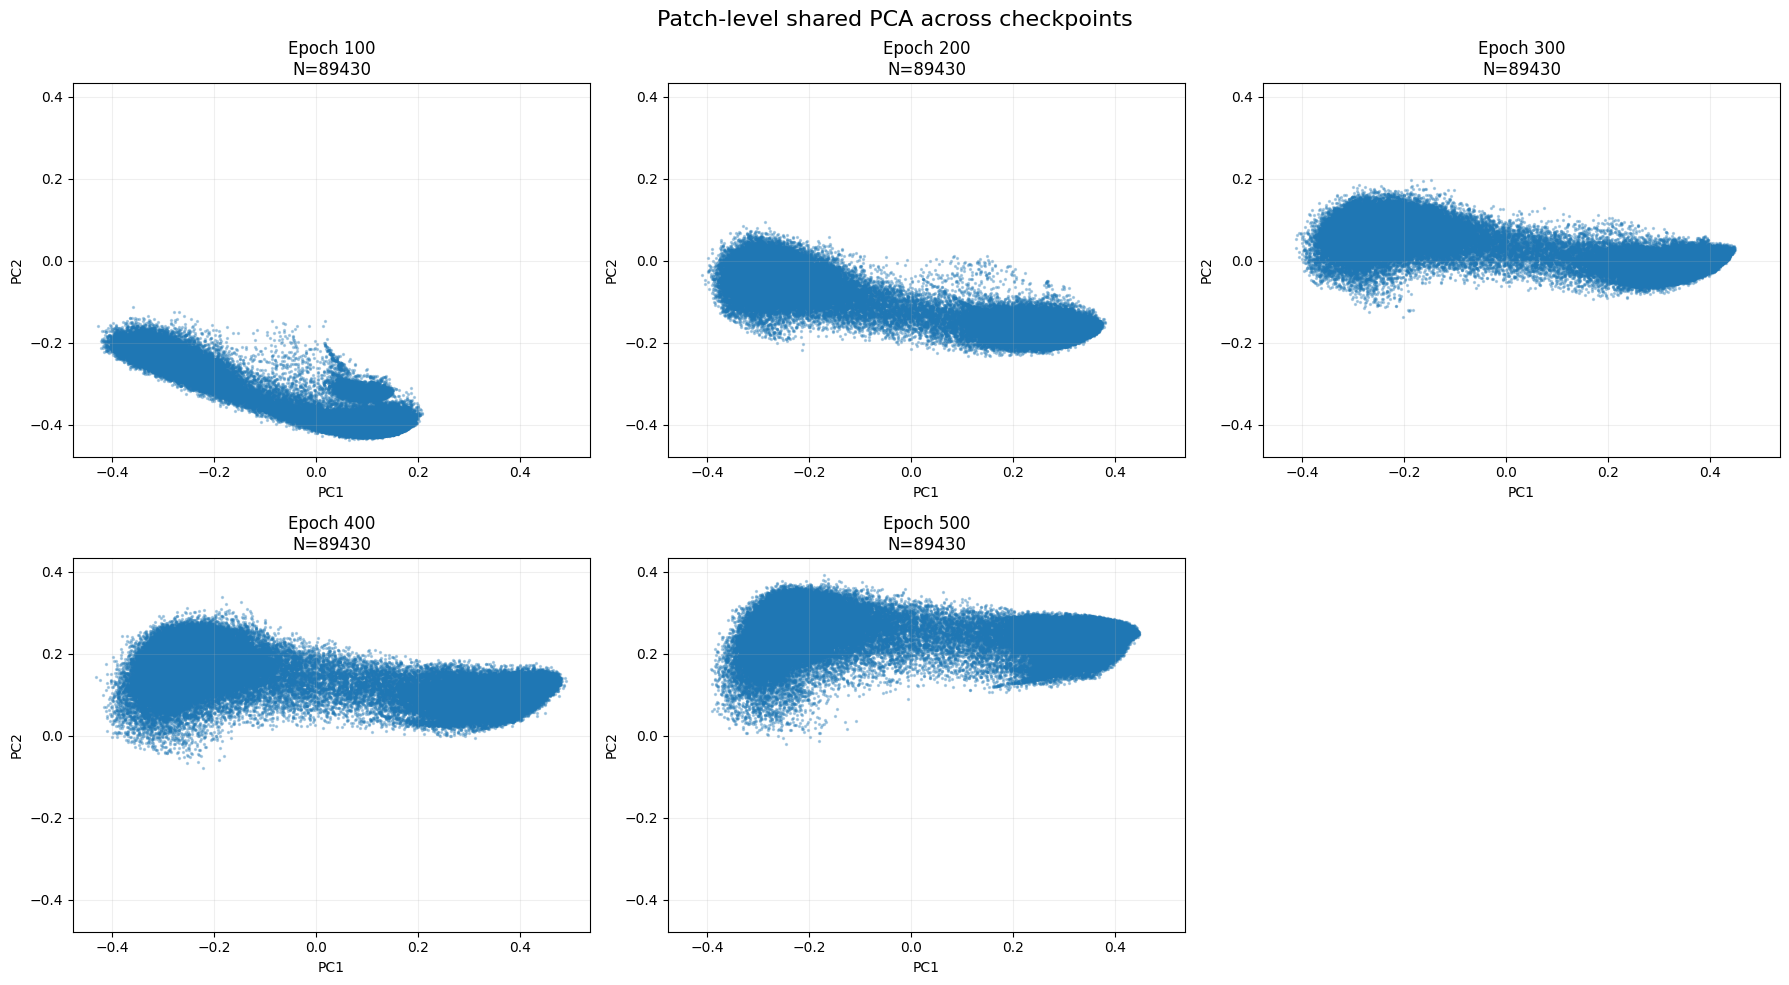

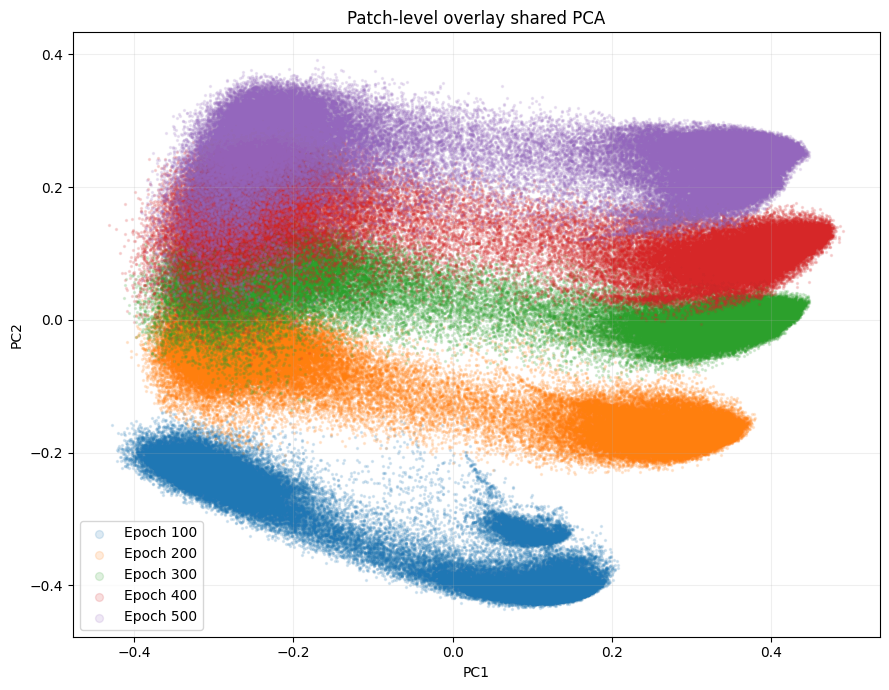

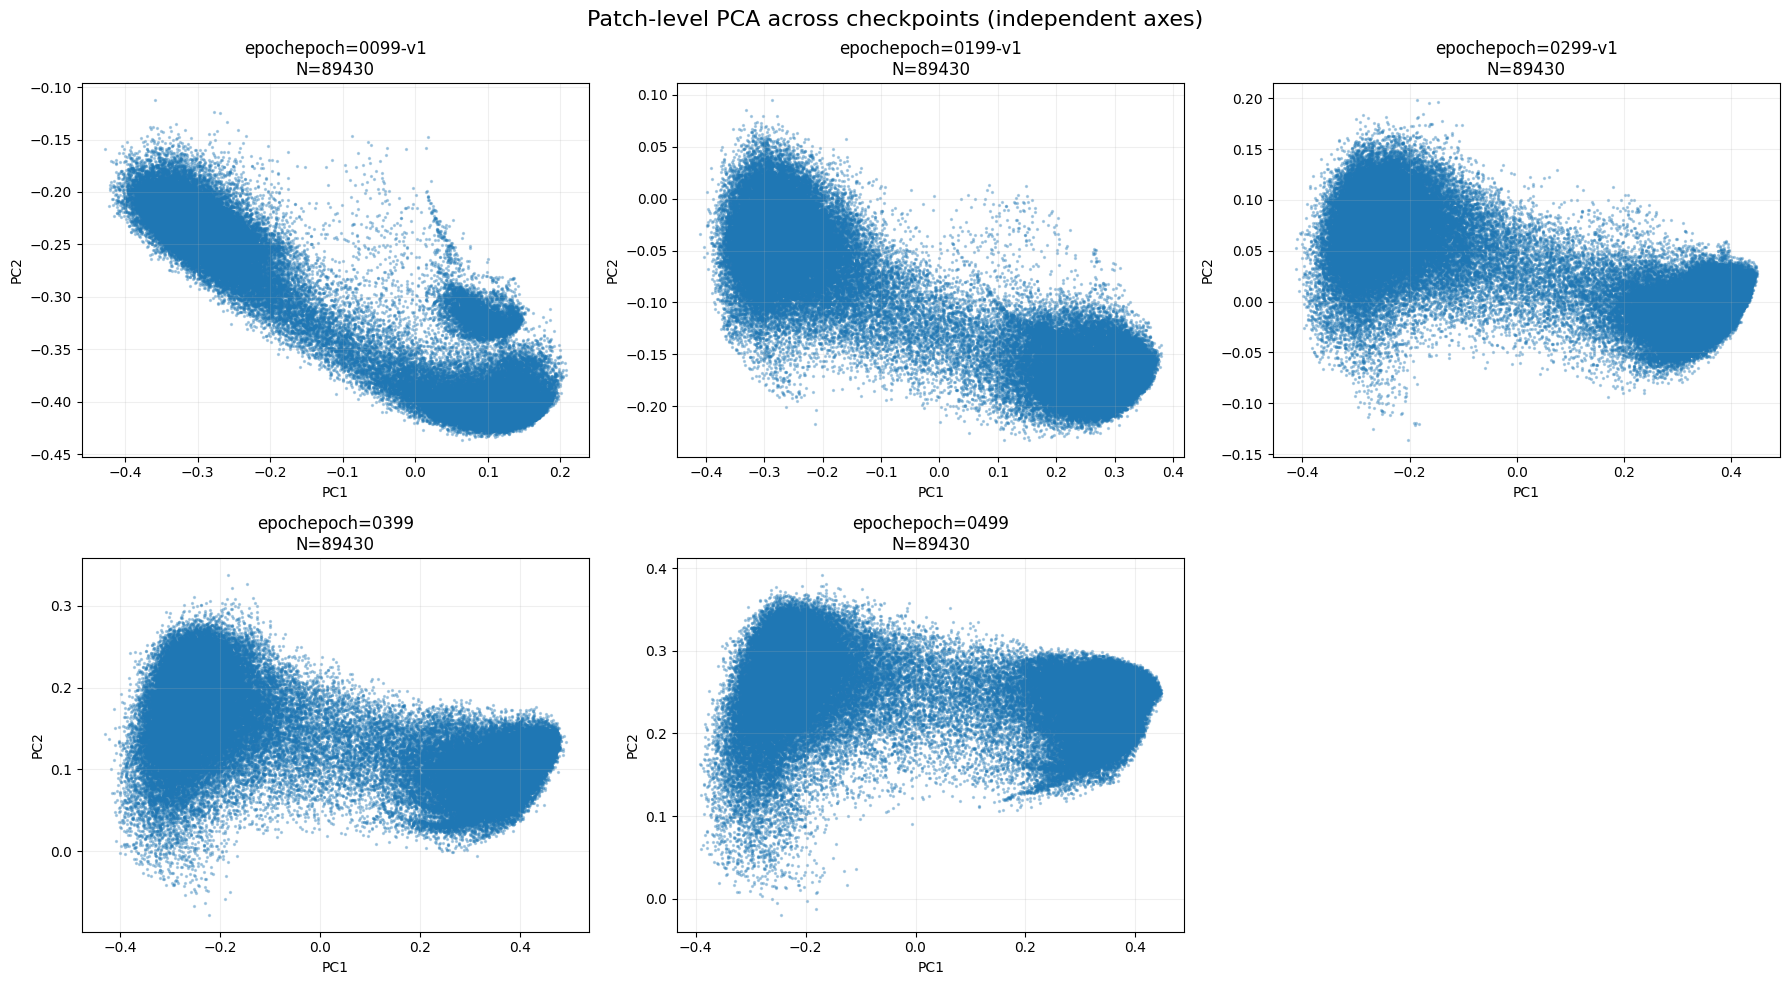

In [36]:
# ---------------------------------------------------
# PATCH LEVEL — PCA
# ---------------------------------------------------
pca_patch_model, pca_patch_coords, pca_patch_meta = project_and_split_shared(
    data, level="patch", method="pca"
)

plot_grid(
    pca_patch_coords,
    title="Patch-level shared PCA across checkpoints",
    save_path=None,
    xlabel="PC1",
    ylabel="PC2",
    point_size=2,
    alpha=0.30,
)

plot_overlay(
    pca_patch_coords,
    title="Patch-level overlay shared PCA",
    save_path=None,
    xlabel="PC1",
    ylabel="PC2",
    point_size=2,
    alpha=0.15,
)

plot_grid_independent_axes(
    pca_patch_coords,
    title="Patch-level PCA across checkpoints (independent axes)",
    xlabel="PC1",
    ylabel="PC2",
    point_size=2,
    alpha=0.30,
)

## Patch-level UMAP

/proj/berzelius-2025-315/users/x_dilwi/conda_envs/h5env_clean_py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


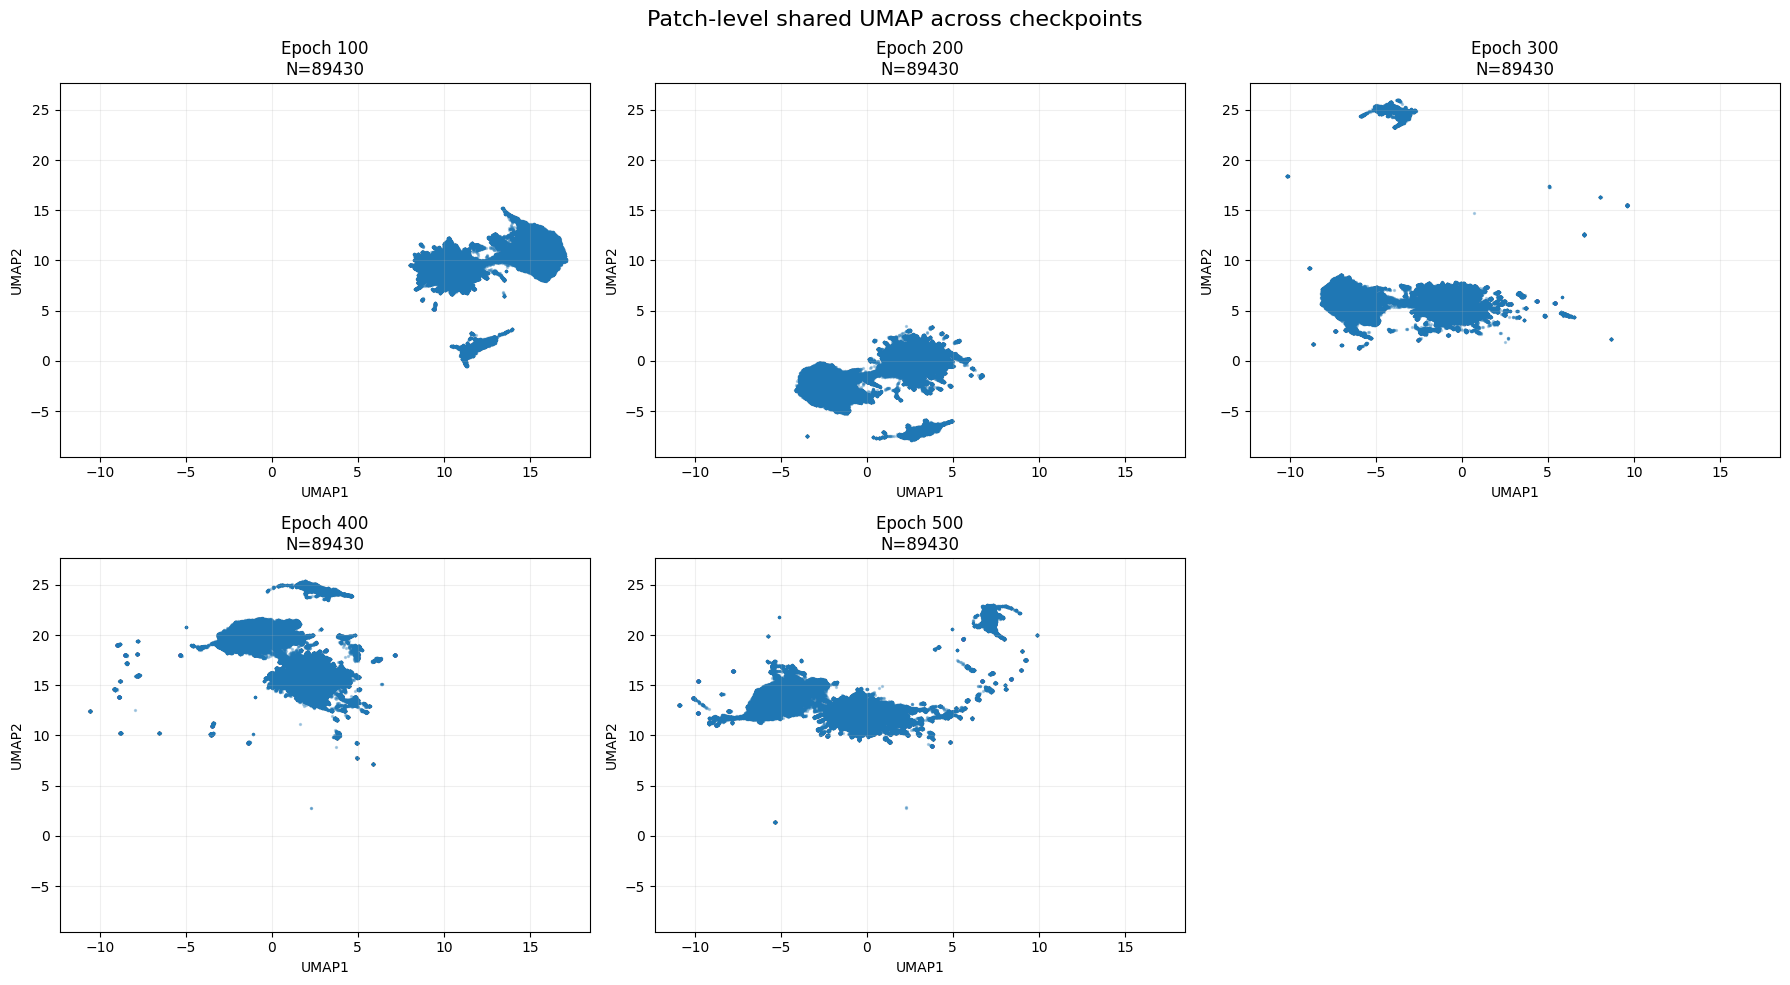

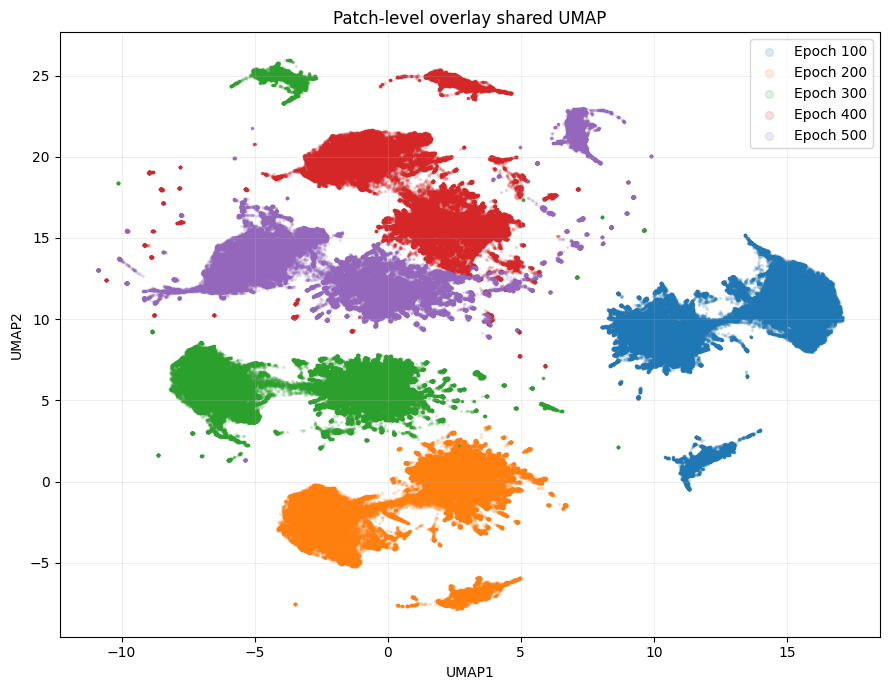

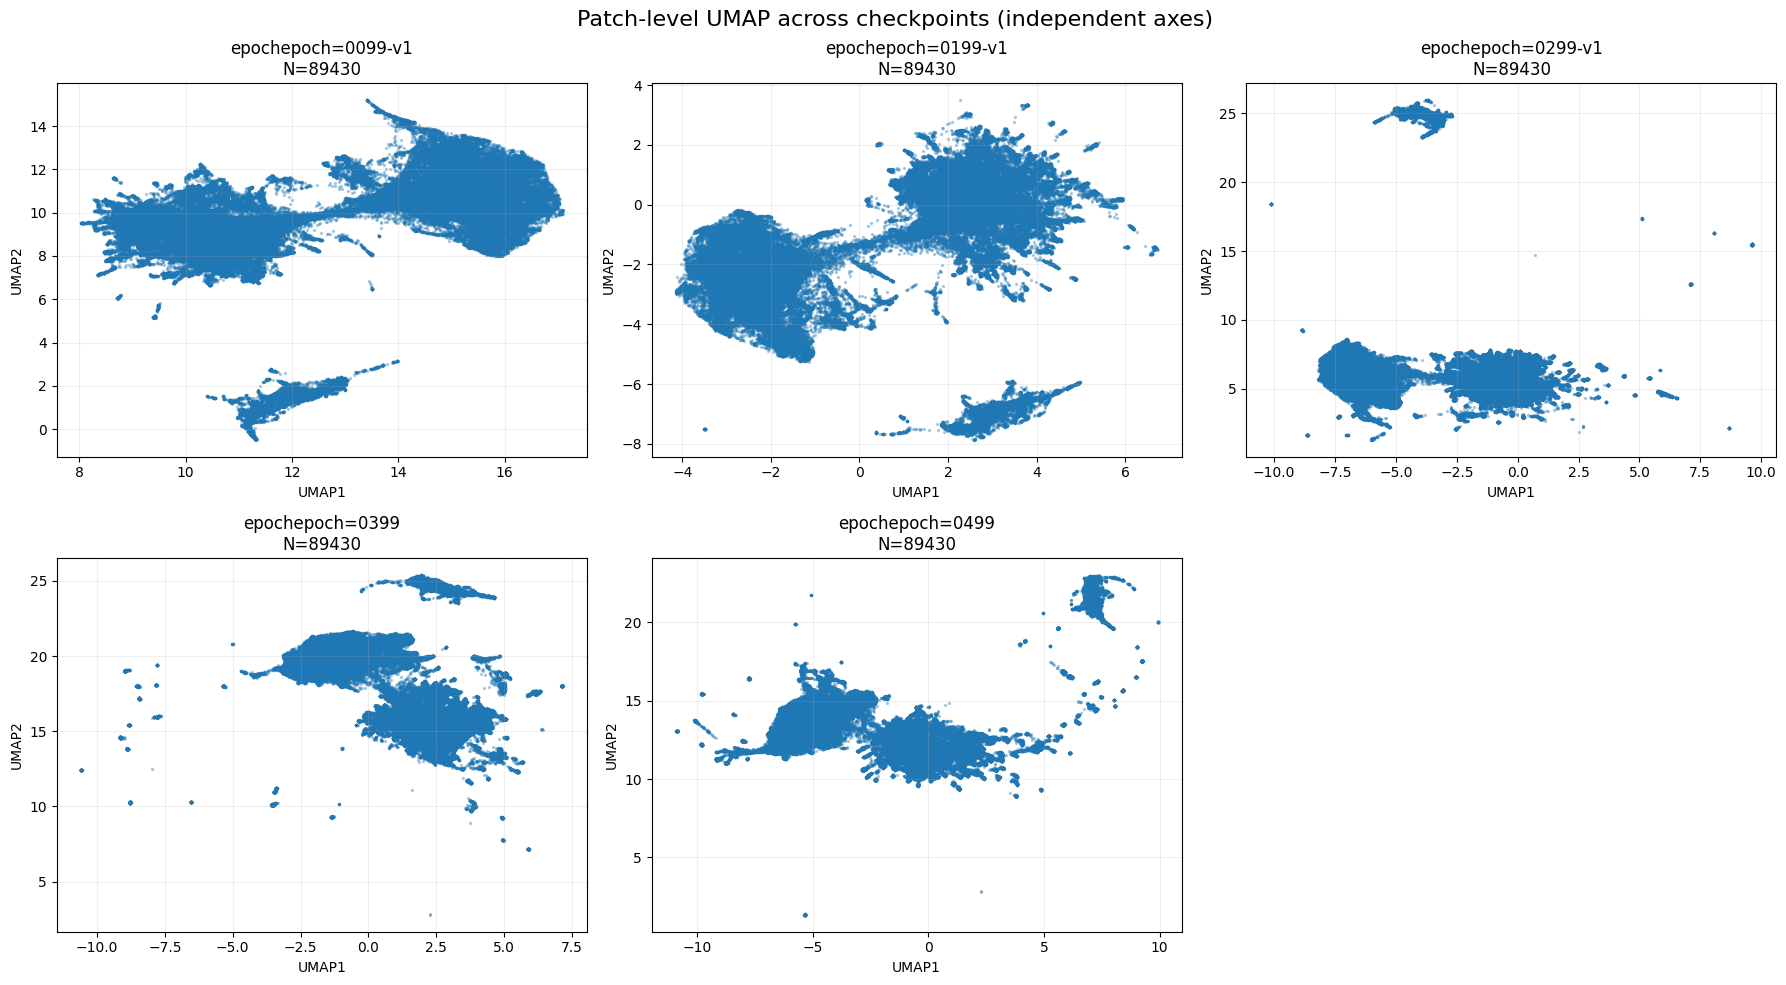

In [37]:
# ---------------------------------------------------
# PATCH LEVEL — UMAP
# ---------------------------------------------------
if HAS_UMAP:
    umap_patch_model, umap_patch_coords, umap_patch_meta = project_and_split_shared(
        data, level="patch", method="umap"
    )

    plot_grid(
        umap_patch_coords,
        title="Patch-level shared UMAP across checkpoints",
        save_path=None,
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=2,
        alpha=0.30,
    )

    plot_overlay(
        umap_patch_coords,
        title="Patch-level overlay shared UMAP",
        save_path=None,
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=2,
        alpha=0.15,
    )
else:
    print("UMAP not installed. Skipping UMAP plots.")

plot_grid_independent_axes(
    umap_patch_coords,
    title="Patch-level UMAP across checkpoints (independent axes)",
    xlabel="UMAP1",
    ylabel="UMAP2",
    point_size=2,
    alpha=0.30,
)

## Core-level PCA

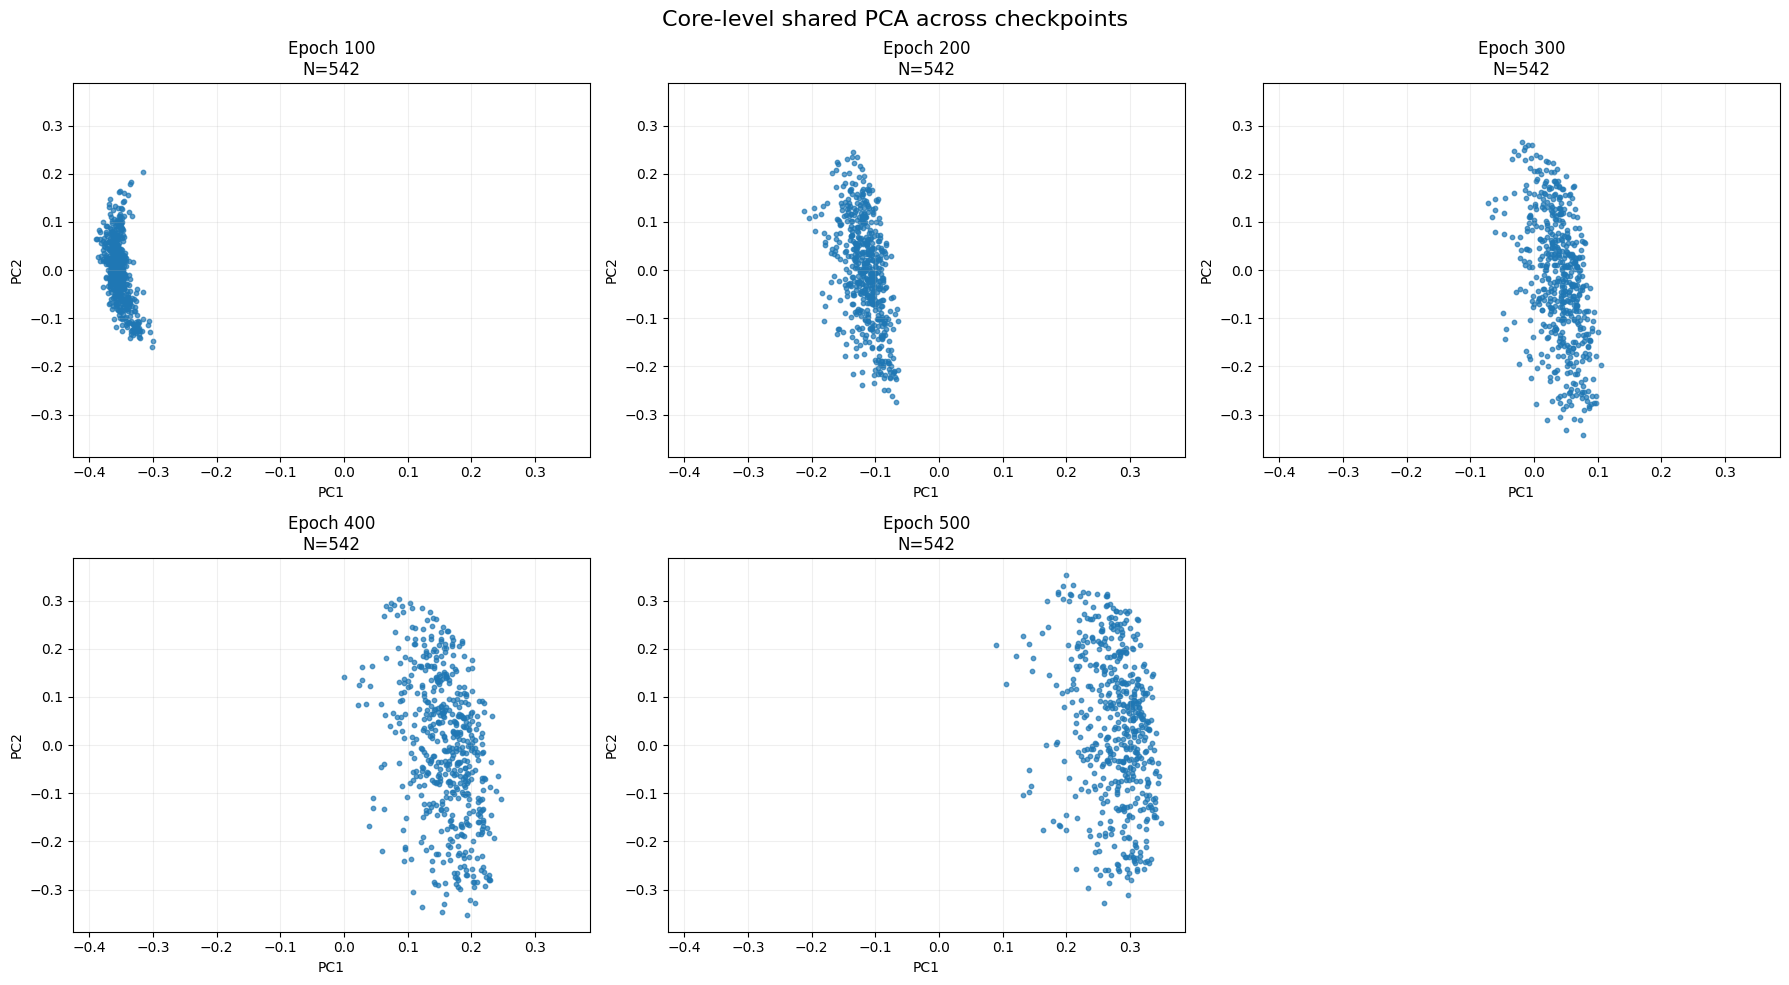

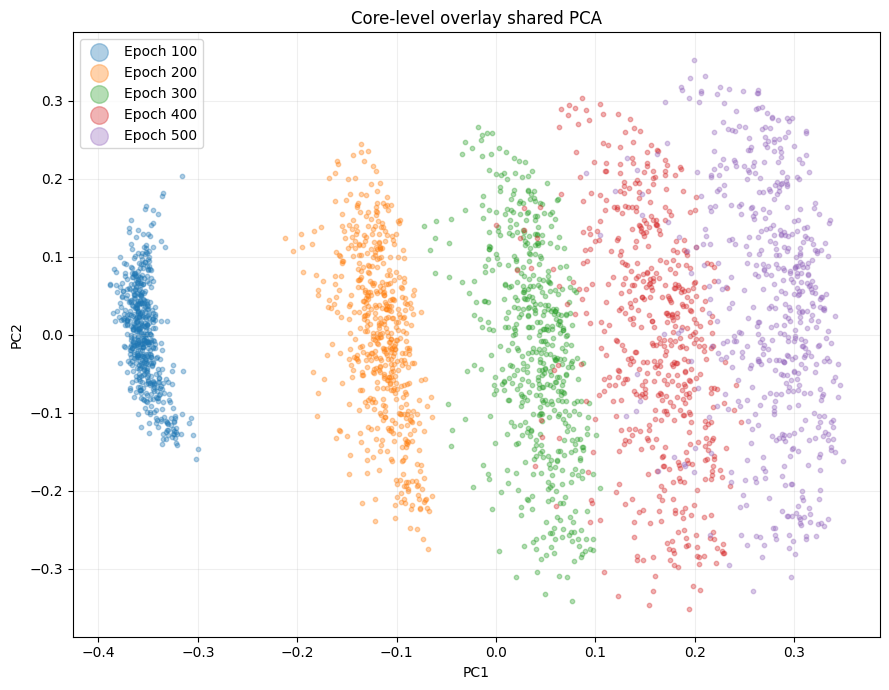

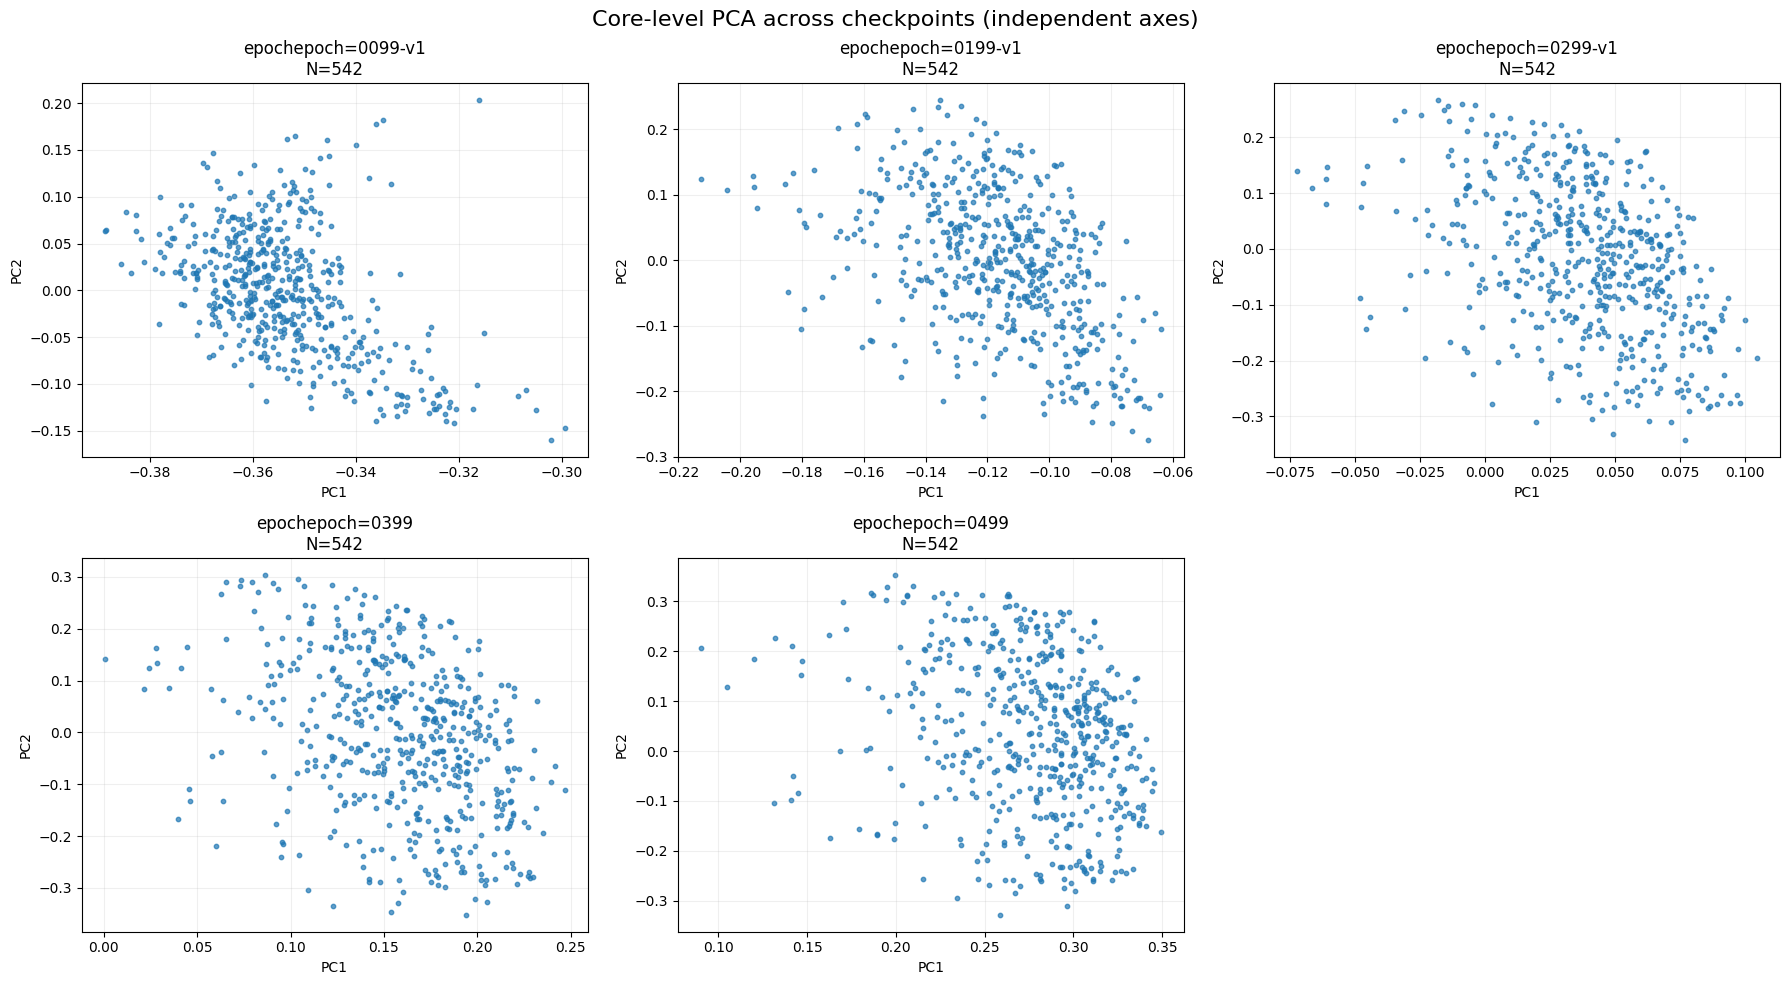

In [38]:
# ---------------------------------------------------
# CORE LEVEL — PCA
# ---------------------------------------------------
pca_core_model, pca_core_coords, pca_core_meta = project_and_split_shared(
    data, level="core", method="pca"
)

plot_grid(
    pca_core_coords,
    title="Core-level shared PCA across checkpoints",
    save_path=None,
    xlabel="PC1",
    ylabel="PC2",
    point_size=10,
    alpha=0.7,
)

plot_overlay(
    pca_core_coords,
    title="Core-level overlay shared PCA",
    save_path=None,
    xlabel="PC1",
    ylabel="PC2",
    point_size=10,
    alpha=0.35,
)

# CORE — PCA (independent axes)
plot_grid_independent_axes(
    pca_core_coords,
    title="Core-level PCA across checkpoints (independent axes)",
    xlabel="PC1",
    ylabel="PC2",
    point_size=10,
    alpha=0.70,
)

## Core-level UMAP

/proj/berzelius-2025-315/users/x_dilwi/conda_envs/h5env_clean_py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


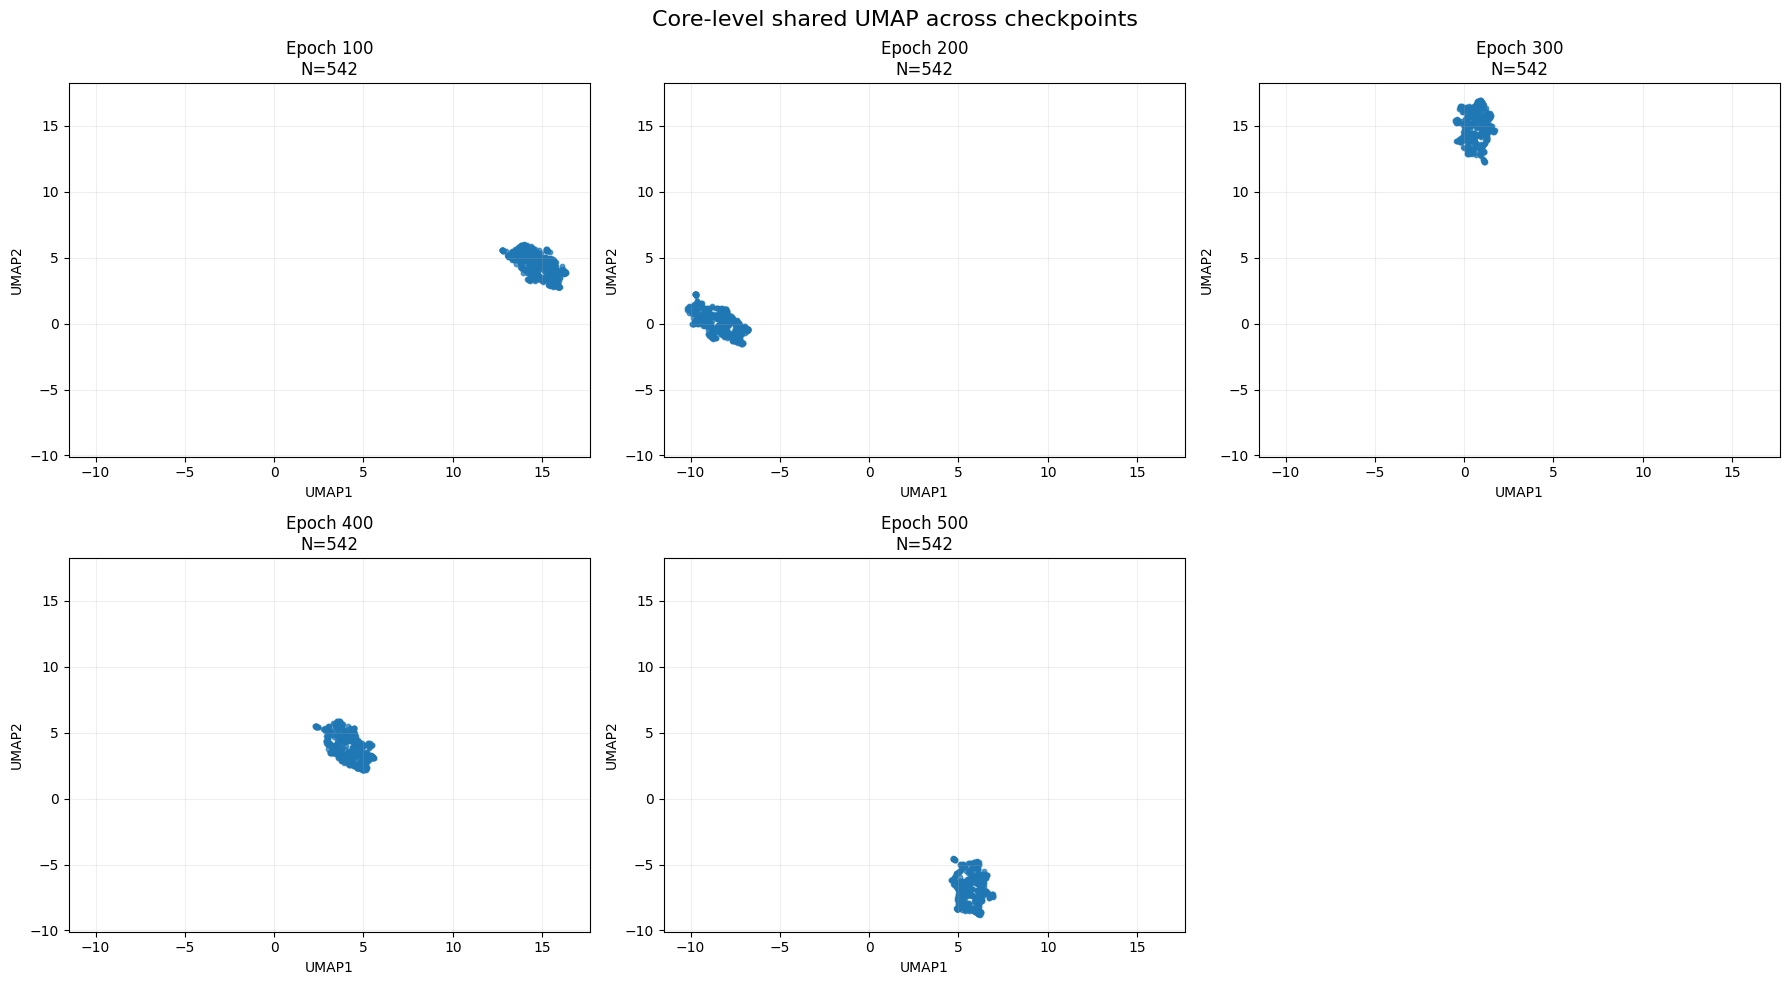

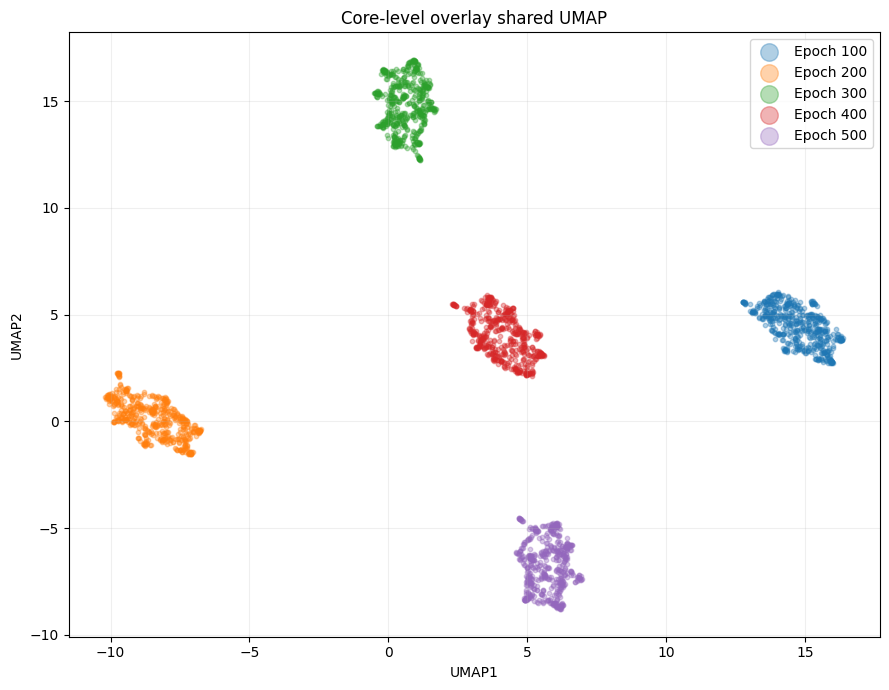

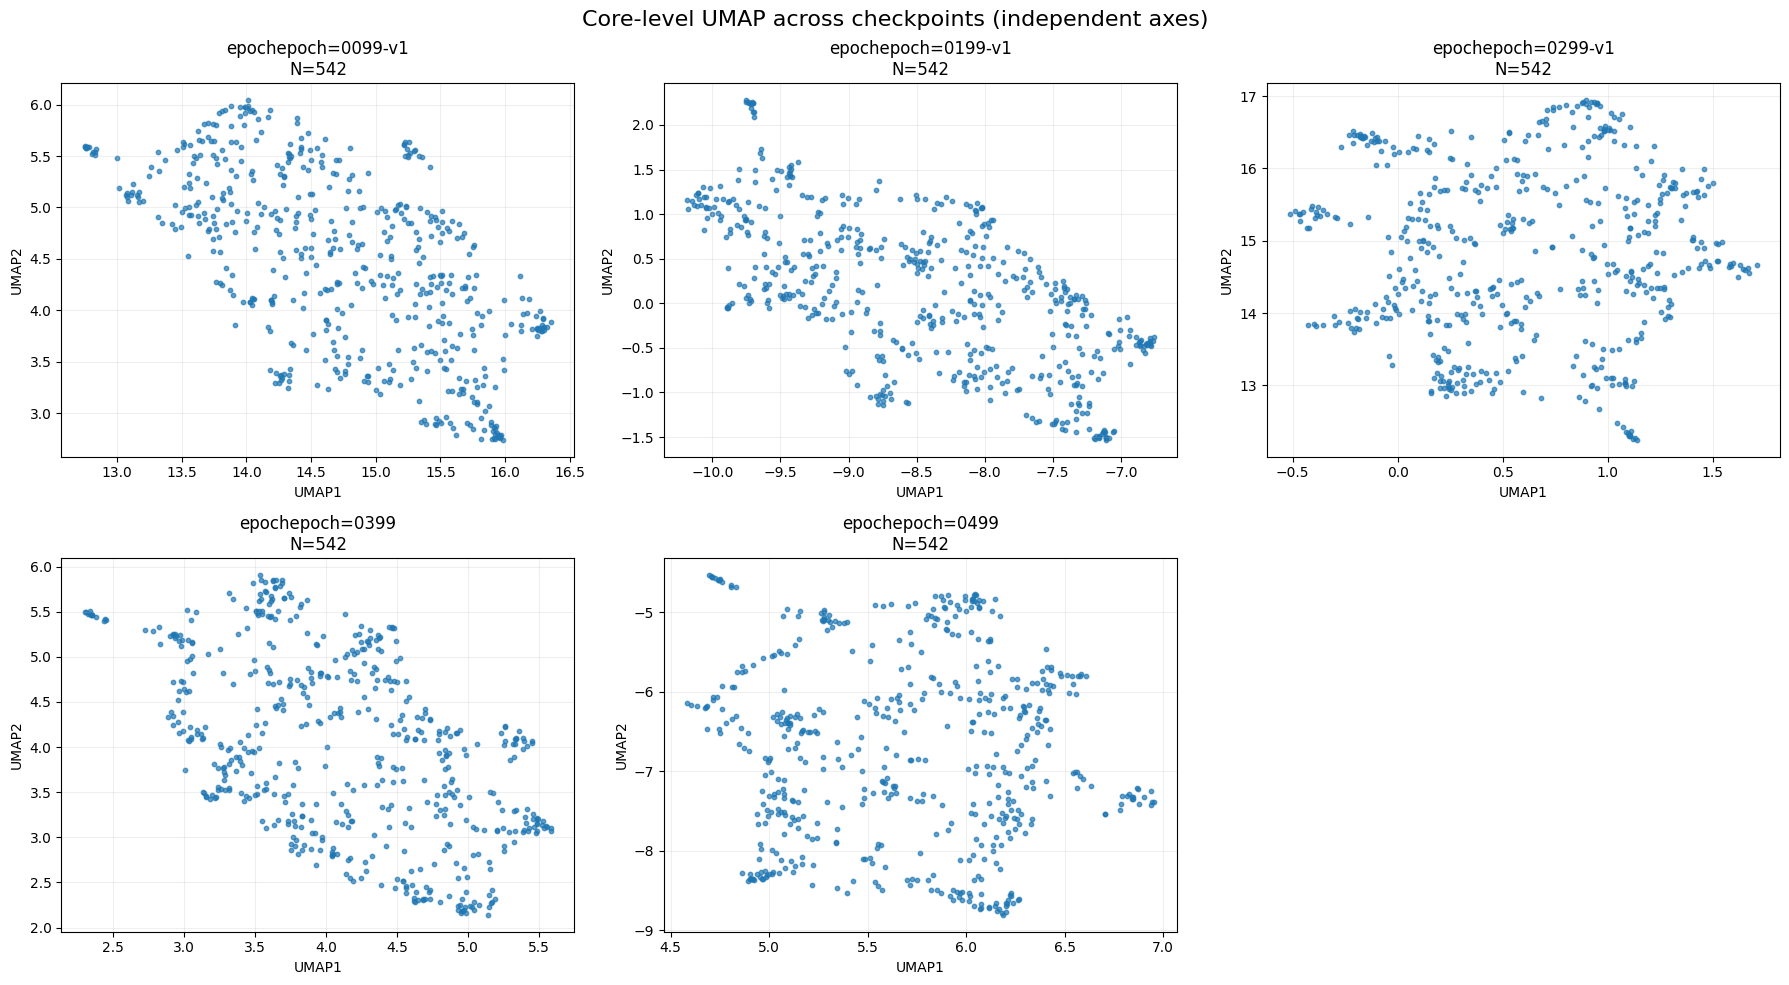

In [39]:
# ---------------------------------------------------
# CORE LEVEL — UMAP
# ---------------------------------------------------
if HAS_UMAP:
    umap_core_model, umap_core_coords, umap_core_meta = project_and_split_shared(
        data, level="core", method="umap"
    )

    plot_grid(
        umap_core_coords,
        title="Core-level shared UMAP across checkpoints",
        save_path=None,
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=10,
        alpha=0.7,
    )

    plot_overlay(
        umap_core_coords,
        title="Core-level overlay shared UMAP",
        save_path=None,
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=10,
        alpha=0.35,
    )

    # CORE — UMAP (independent axes)
    plot_grid_independent_axes(
        umap_core_coords,
        title="Core-level UMAP across checkpoints (independent axes)",
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=10,
        alpha=0.70,
    )

else:
    print("UMAP not installed. Skipping UMAP plots.")



## Patient-level PCA

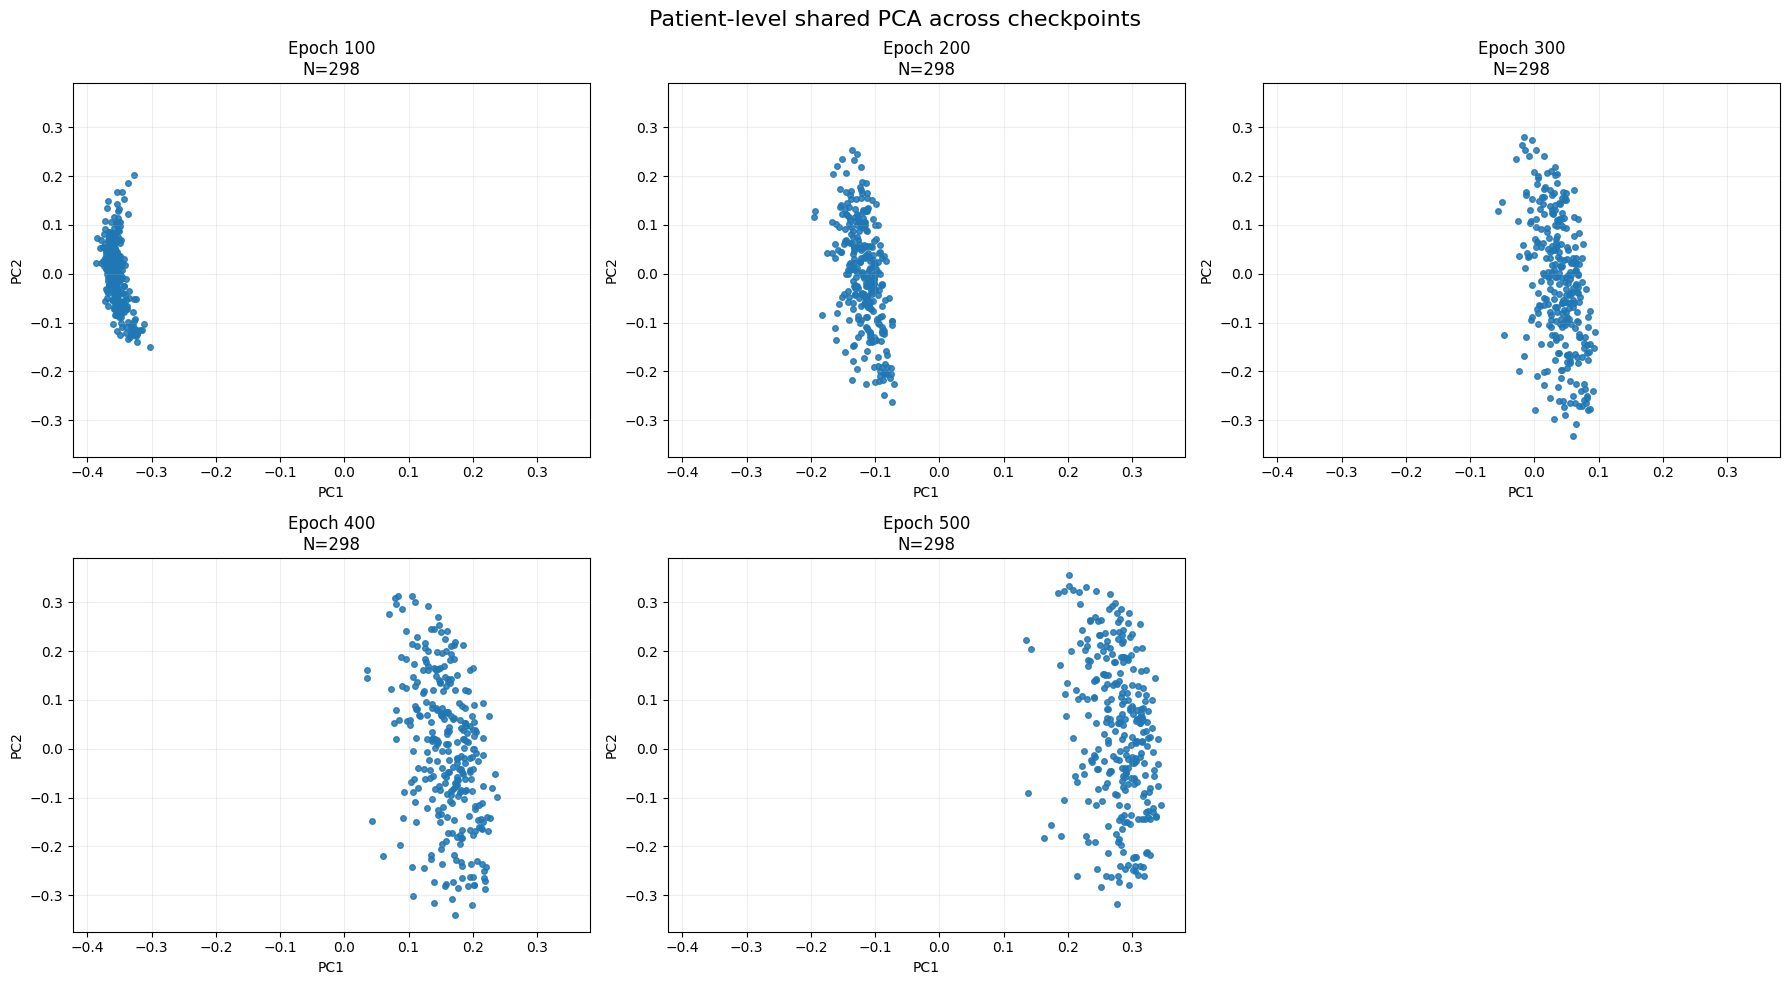

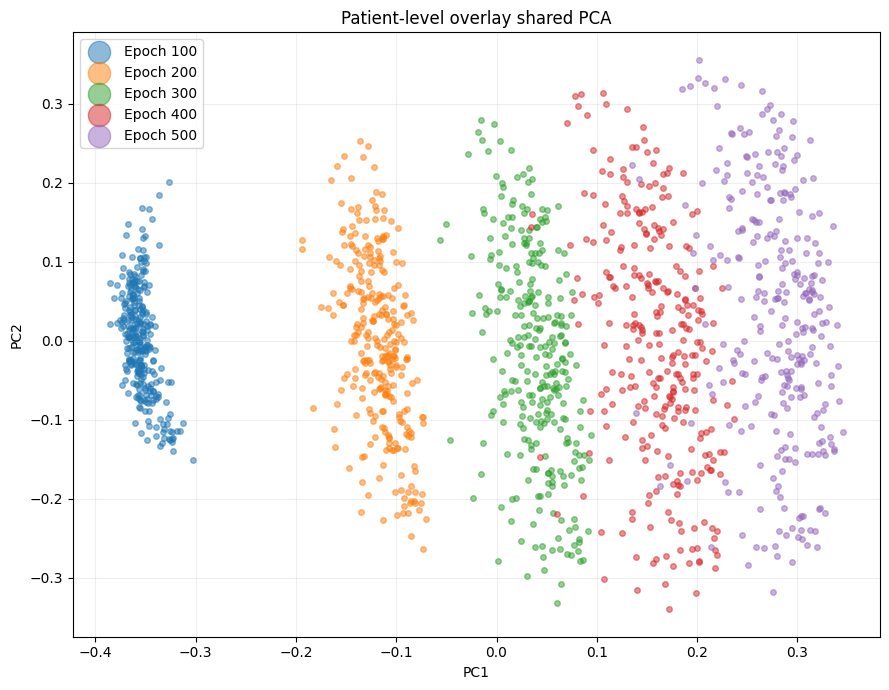

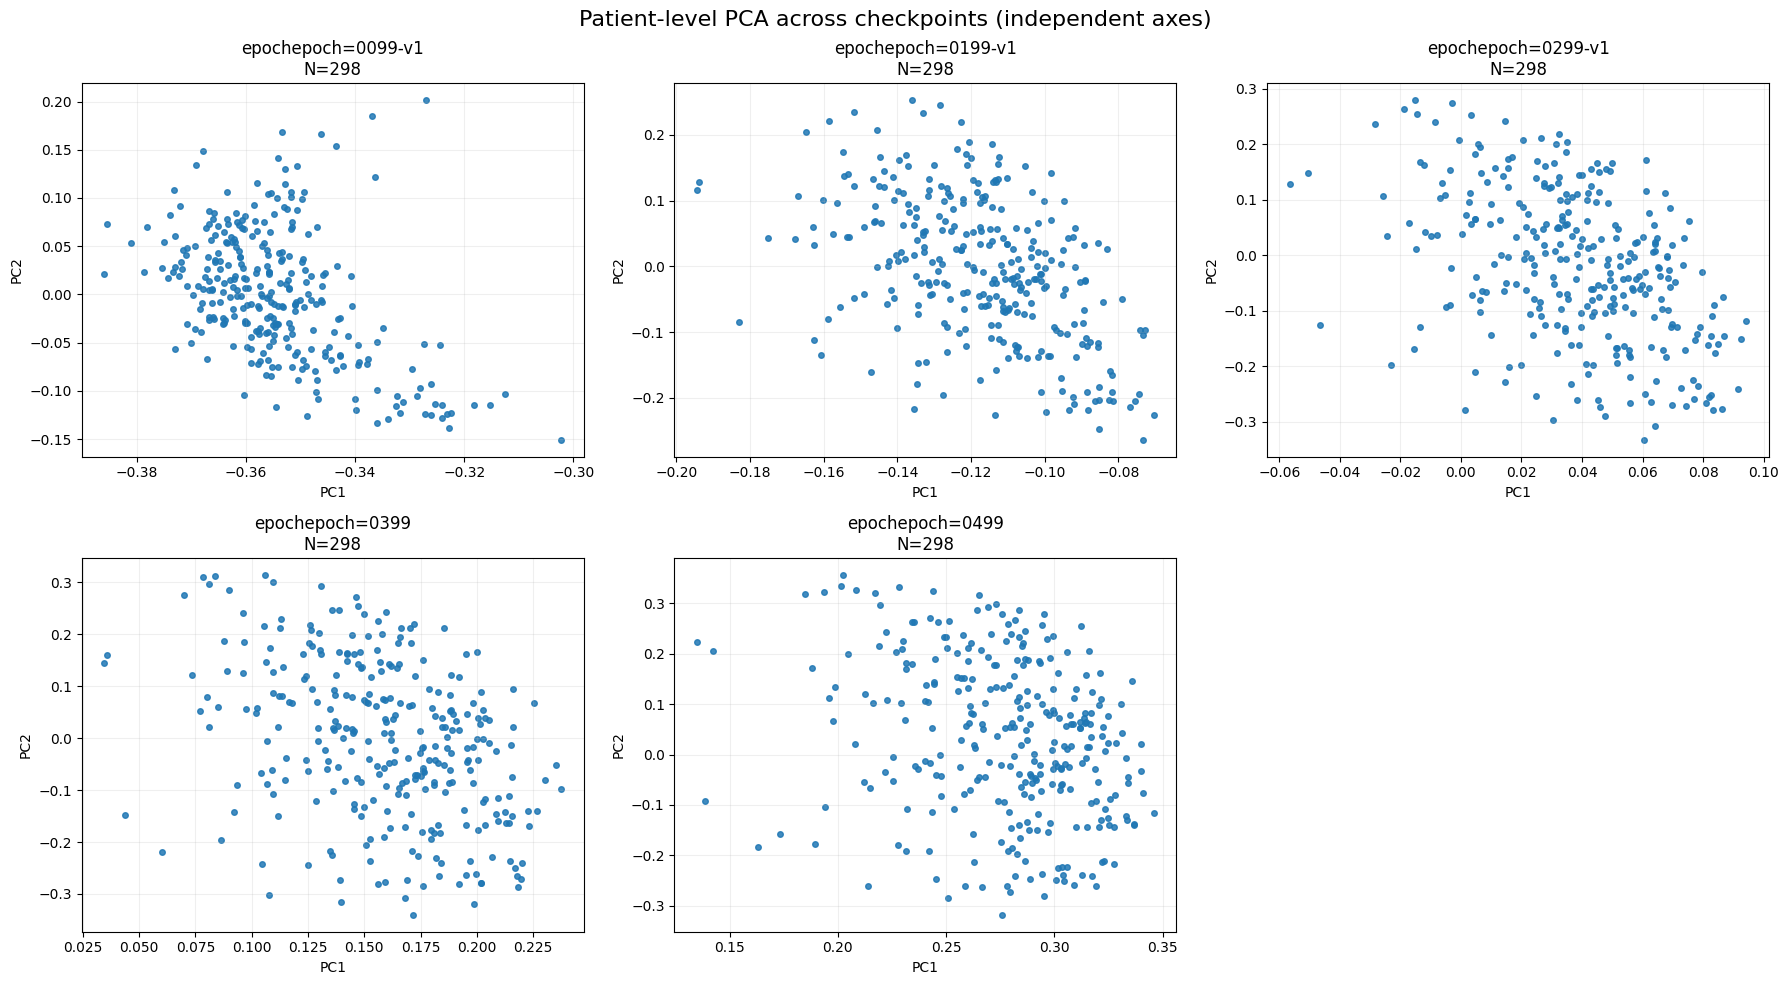

In [40]:
# ---------------------------------------------------
# PATIENT LEVEL — PCA
# ---------------------------------------------------
pca_patient_model, pca_patient_coords, pca_patient_meta = project_and_split_shared(
    data, level="patient", method="pca"
)

plot_grid(
    pca_patient_coords,
    title="Patient-level shared PCA across checkpoints",
    save_path=None,
    xlabel="PC1",
    ylabel="PC2",
    point_size=16,
    alpha=0.85,
)

plot_overlay(
    pca_patient_coords,
    title="Patient-level overlay shared PCA",
    save_path=None,
    xlabel="PC1",
    ylabel="PC2",
    point_size=16,
    alpha=0.5,
)

# PATIENT — PCA (independent axes)
plot_grid_independent_axes(
    pca_patient_coords,
    title="Patient-level PCA across checkpoints (independent axes)",
    xlabel="PC1",
    ylabel="PC2",
    point_size=16,
    alpha=0.85,
)

## Patient-level UMAP

/proj/berzelius-2025-315/users/x_dilwi/conda_envs/h5env_clean_py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


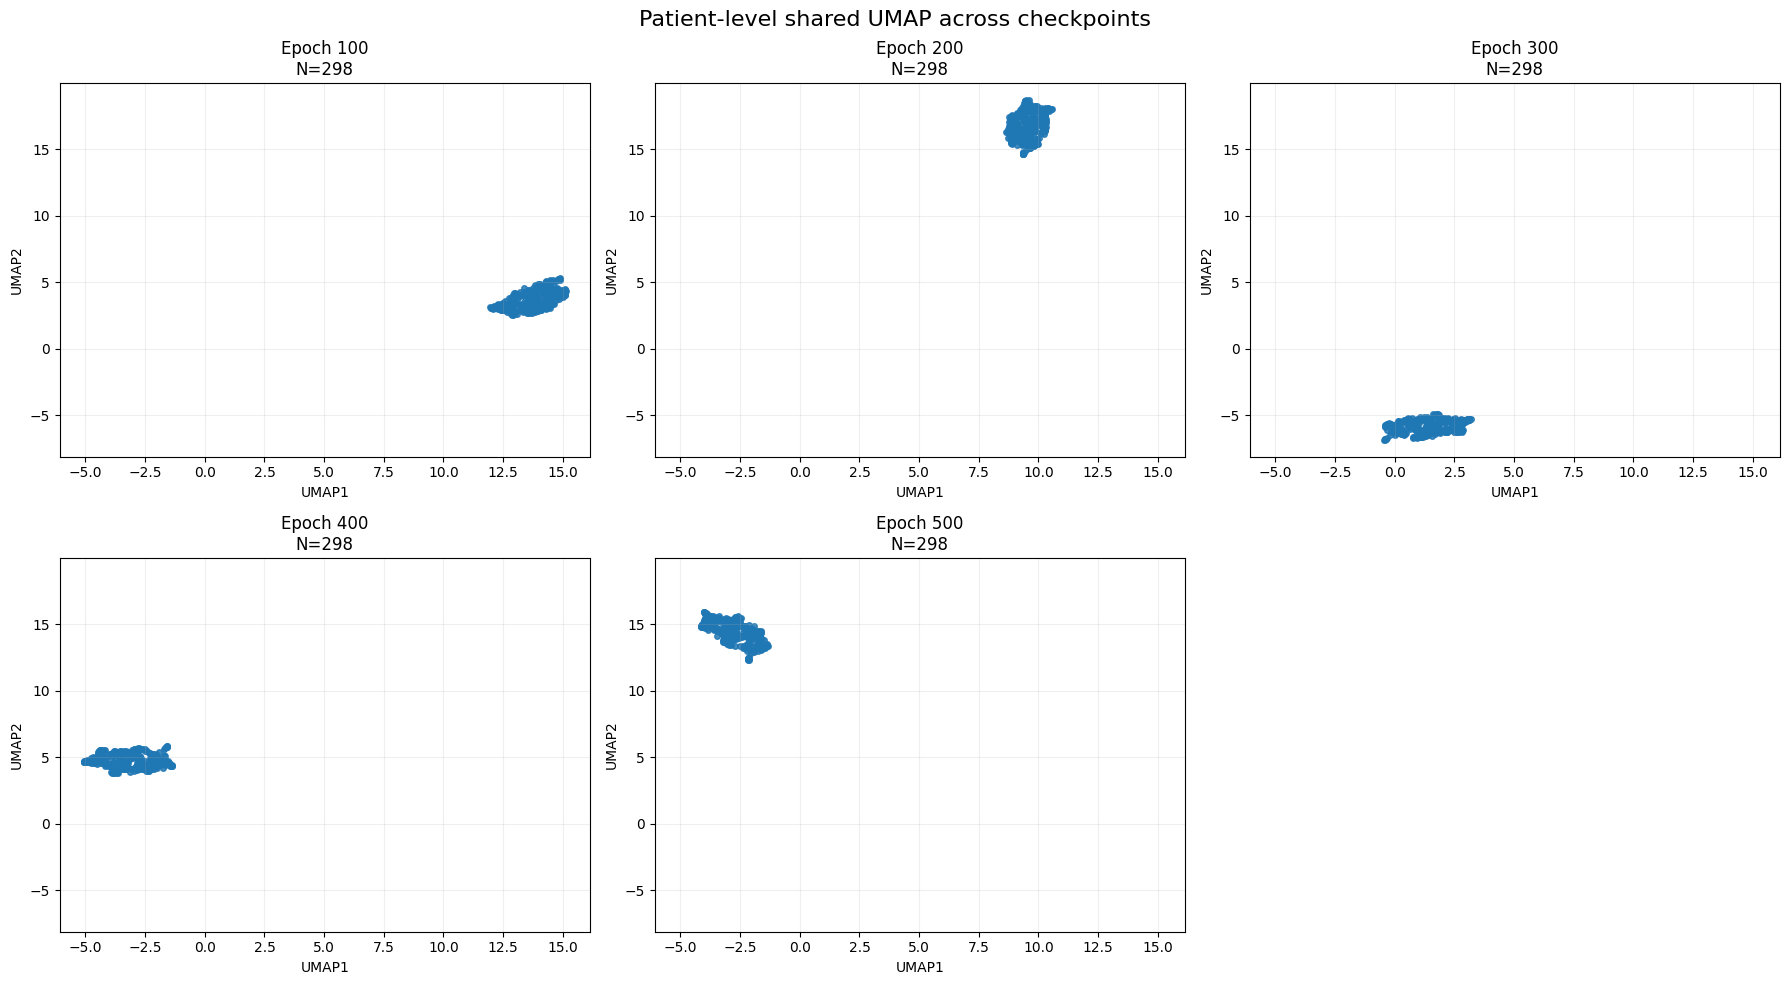

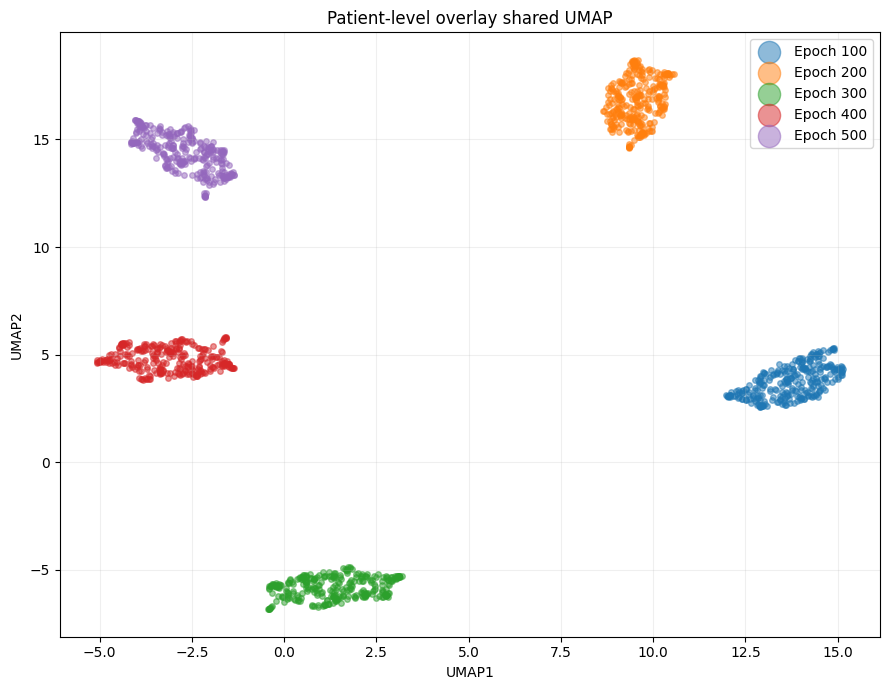

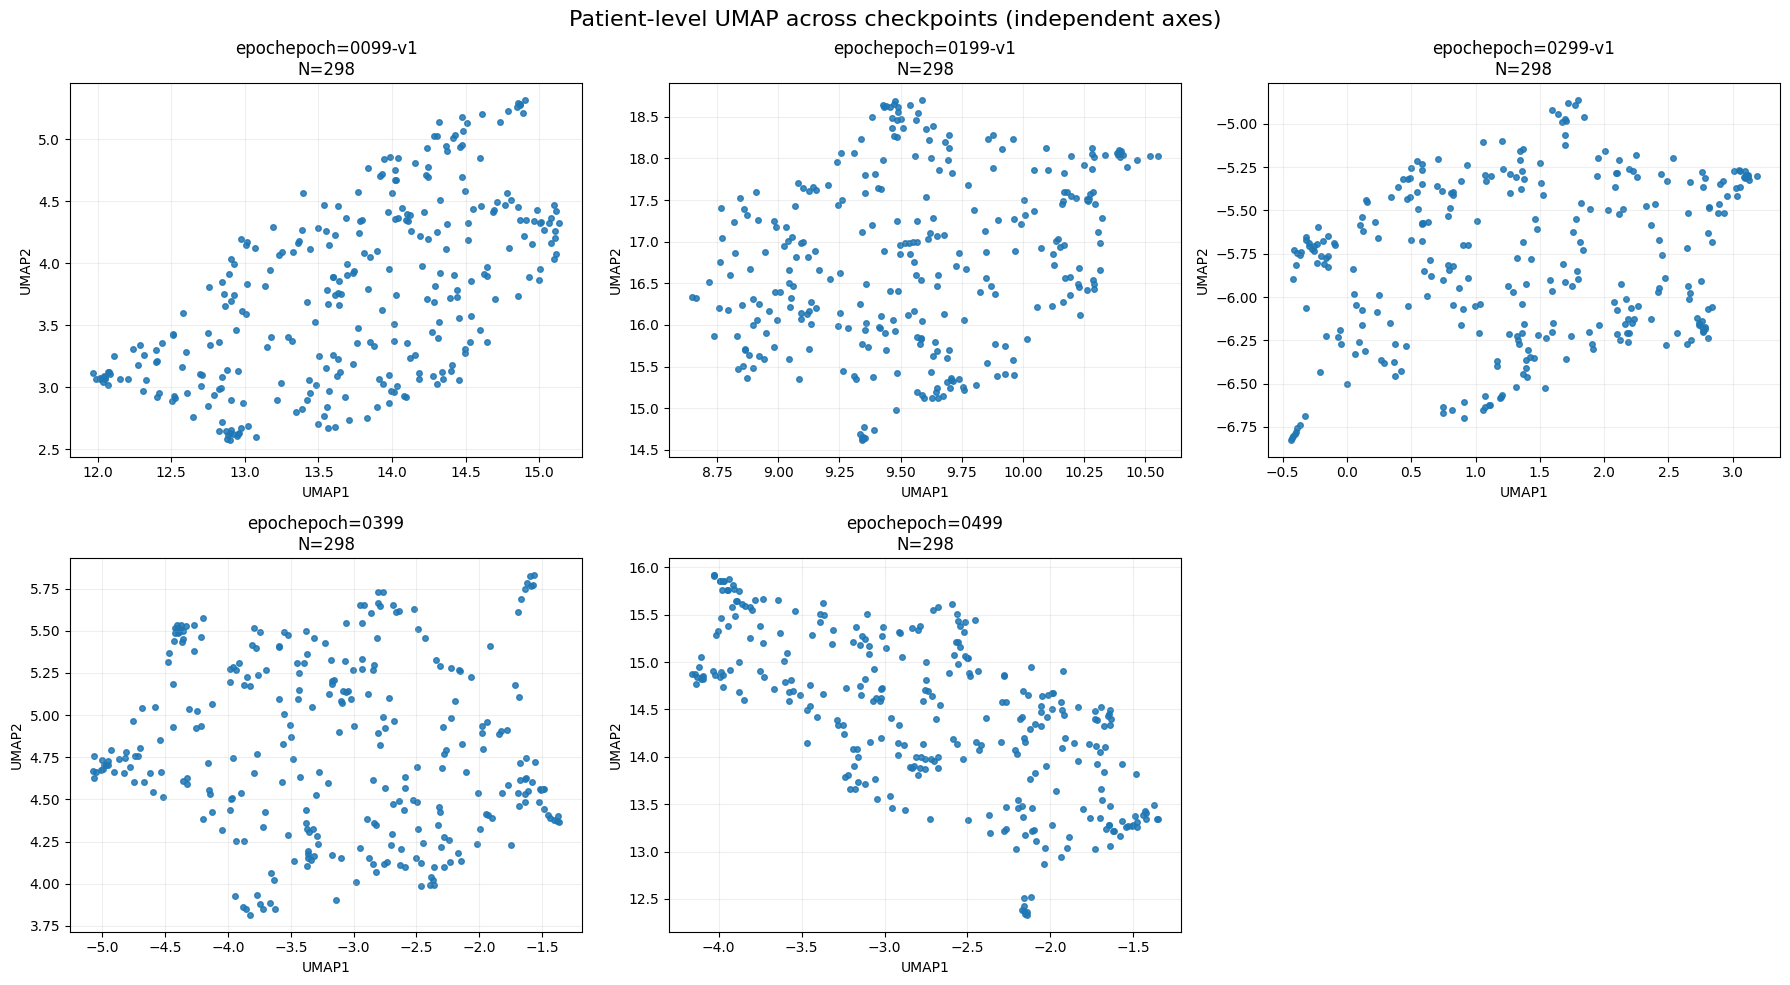

In [41]:
# ---------------------------------------------------
# PATIENT LEVEL — UMAP
# ---------------------------------------------------
if HAS_UMAP:
    umap_patient_model, umap_patient_coords, umap_patient_meta = project_and_split_shared(
        data, level="patient", method="umap"
    )

    plot_grid(
        umap_patient_coords,
        title="Patient-level shared UMAP across checkpoints",
        save_path=None,
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=16,
        alpha=0.85,
    )

    plot_overlay(
        umap_patient_coords,
        title="Patient-level overlay shared UMAP",
        save_path=None,
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=16,
        alpha=0.5,
    )

    # PATIENT — UMAP (independent axes)
    plot_grid_independent_axes(
        umap_patient_coords,
        title="Patient-level UMAP across checkpoints (independent axes)",
        xlabel="UMAP1",
        ylabel="UMAP2",
        point_size=16,
        alpha=0.85,
    )

else:
    print("UMAP not installed. Skipping UMAP plots.")

## Patch-level by patient/core for all checkpoints

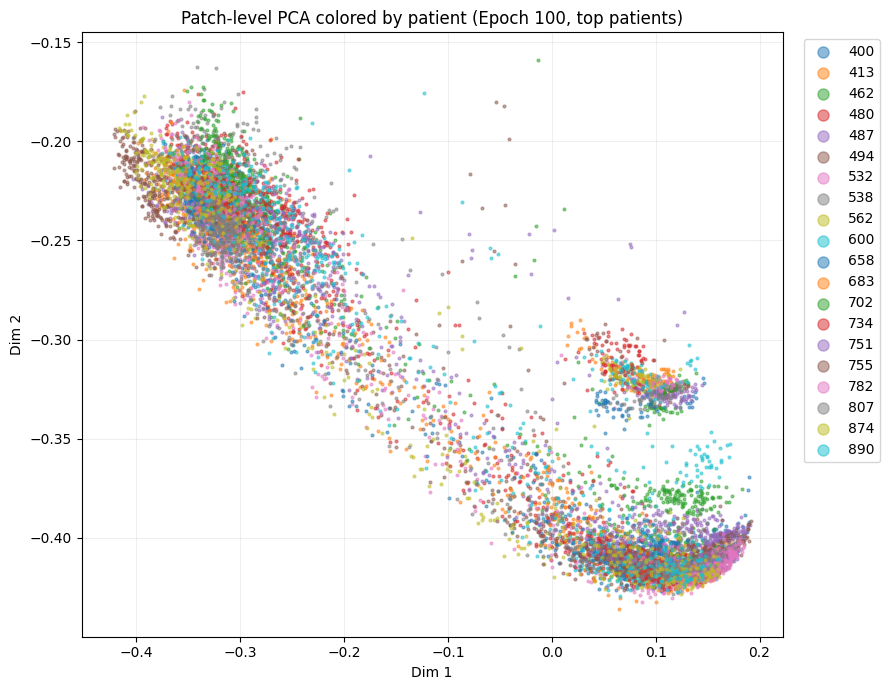

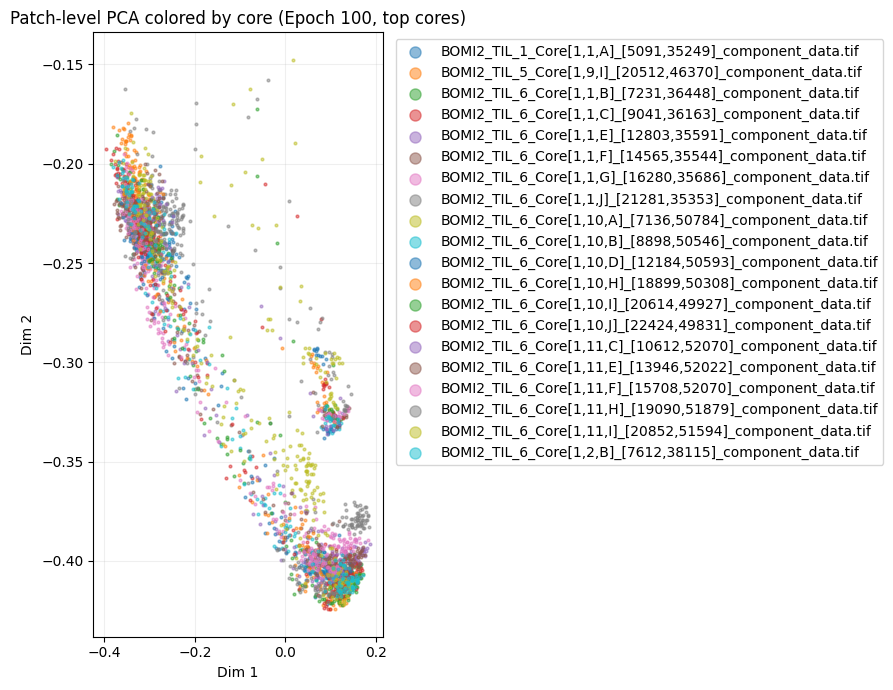

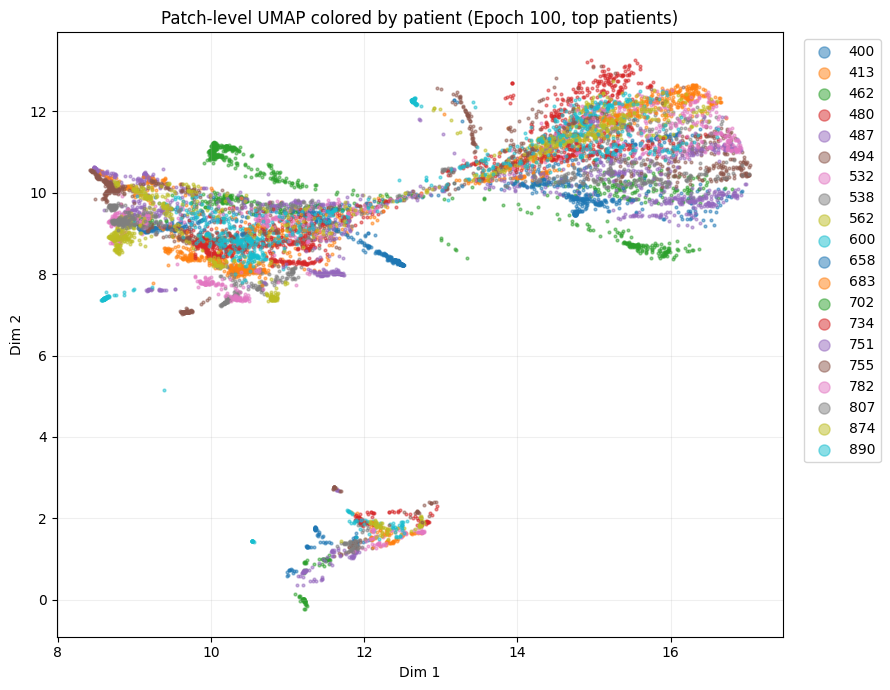

KeyError: 'core_id'

<Figure size 900x700 with 0 Axes>

In [42]:
# ---------------------------------------------------
# PATCH LEVEL — colored by patient / core for ALL checkpoints
# ---------------------------------------------------
for ckpt in data.keys():
    plot_colored_subset(
        pca_patch_meta[ckpt],
        color_col="patient_id",
        title=f"Patch-level PCA colored by patient ({pretty_ckpt_name(ckpt)}, top patients)",
        save_path=None,
        max_groups=20,
        s=4,
        alpha=0.5,
    )

    plot_colored_subset(
        pca_patch_meta[ckpt],
        color_col="image_name",
        title=f"Patch-level PCA colored by core ({pretty_ckpt_name(ckpt)}, top cores)",
        save_path=None,
        max_groups=20,
        s=4,
        alpha=0.5,
    )

    if HAS_UMAP:
        plot_colored_subset(
            umap_patch_meta[ckpt],
            color_col="patient_id",
            title=f"Patch-level UMAP colored by patient ({pretty_ckpt_name(ckpt)}, top patients)",
            save_path=None,
            max_groups=20,
            s=4,
            alpha=0.5,
        )

        plot_colored_subset(
            umap_patch_meta[ckpt],
            color_col="core_id",
            title=f"Patch-level UMAP colored by core ({pretty_ckpt_name(ckpt)}, top cores)",
            save_path=None,
            max_groups=20,
            s=4,
            alpha=0.5,
        )

## Core-level coloured plots

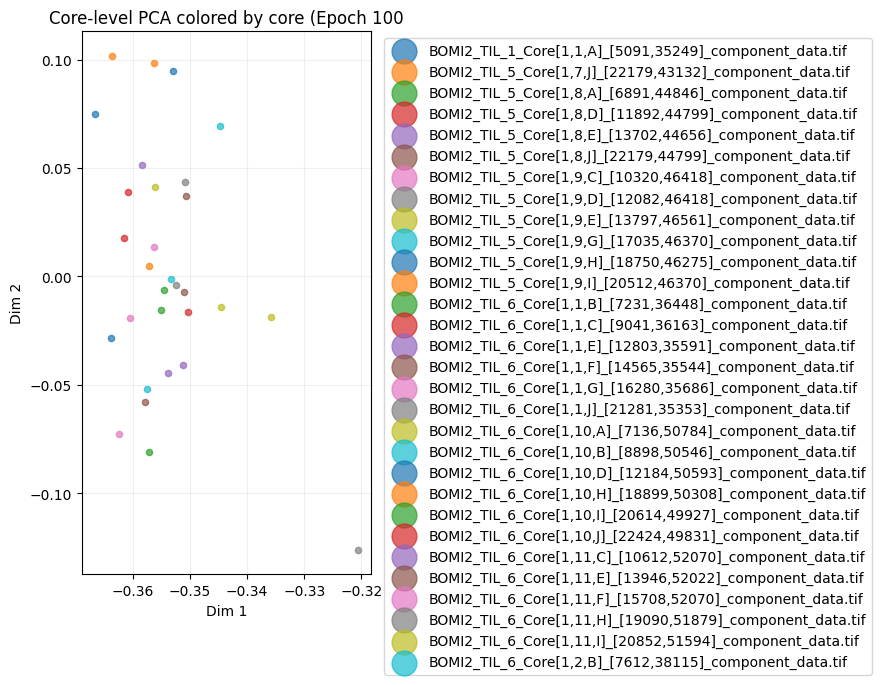

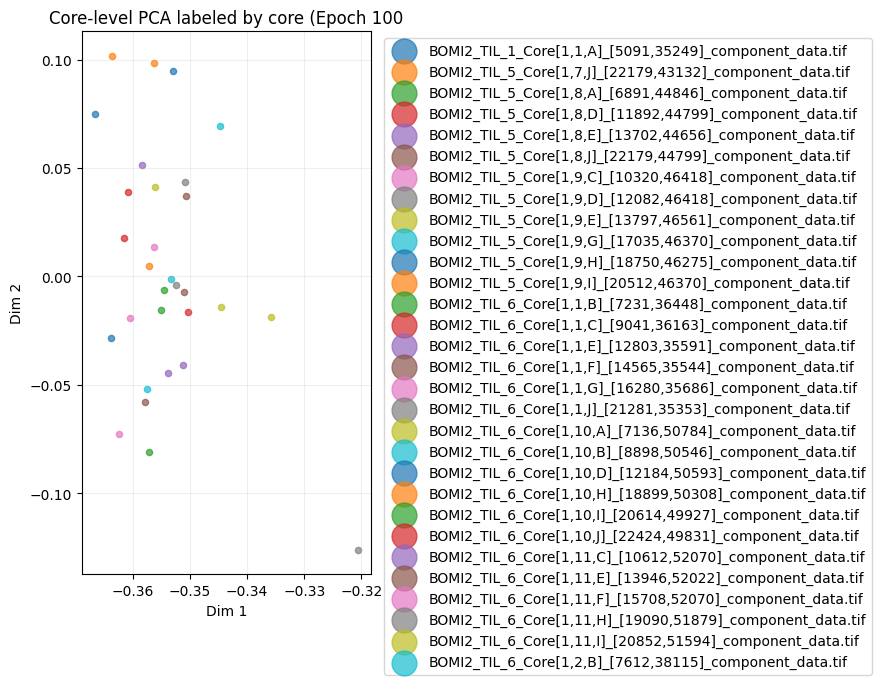

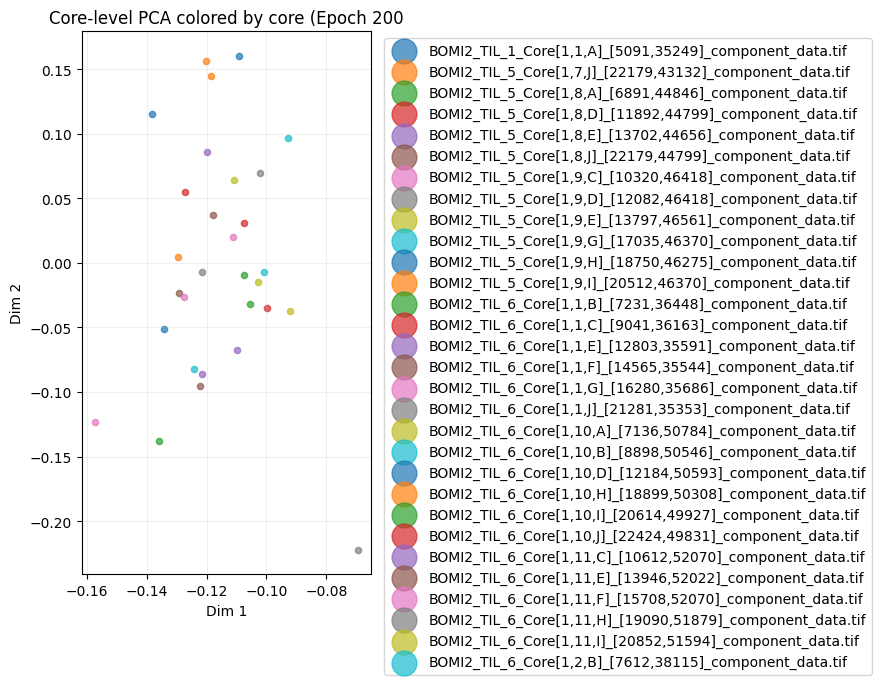

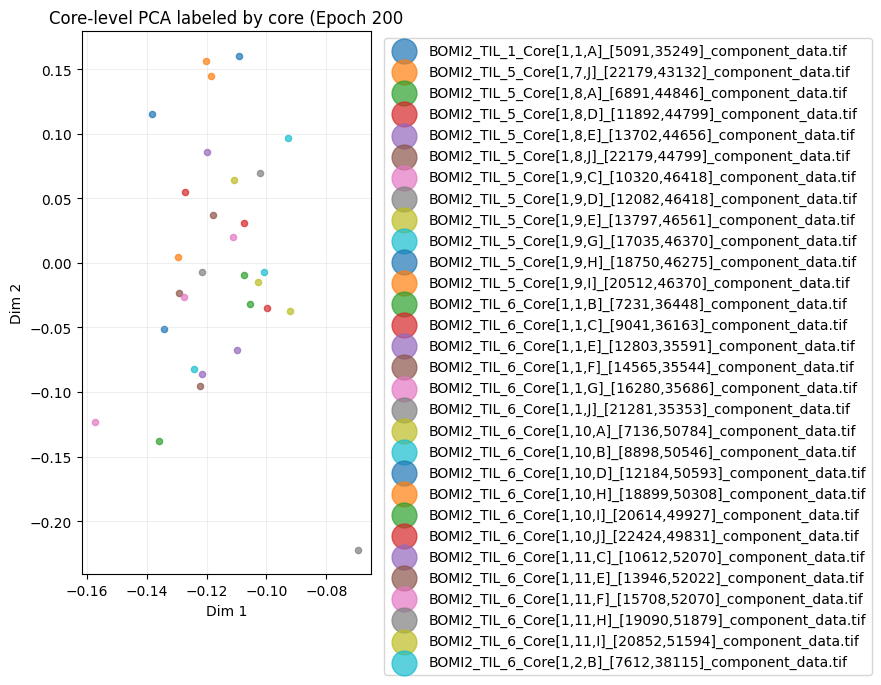

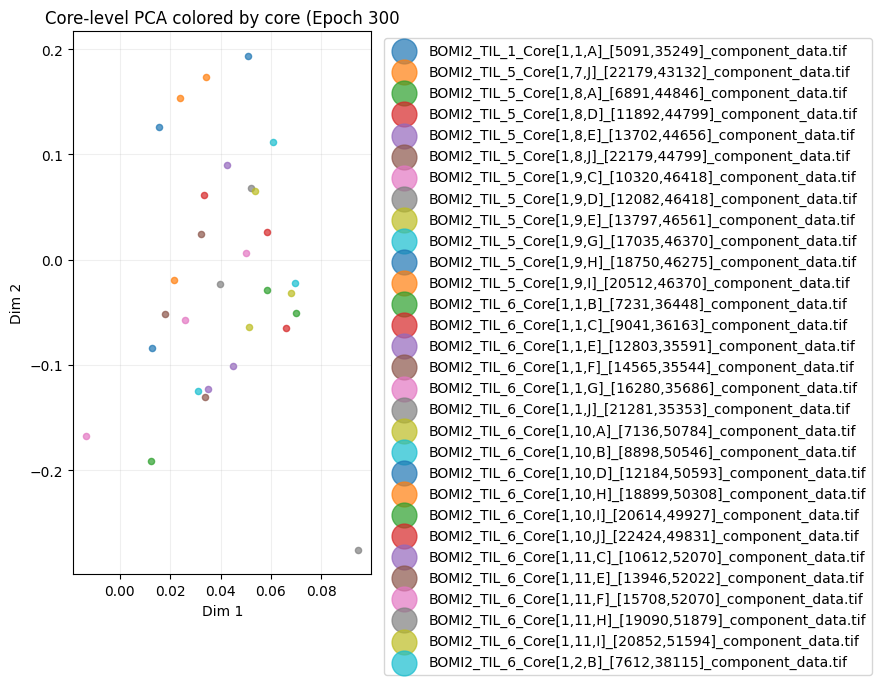

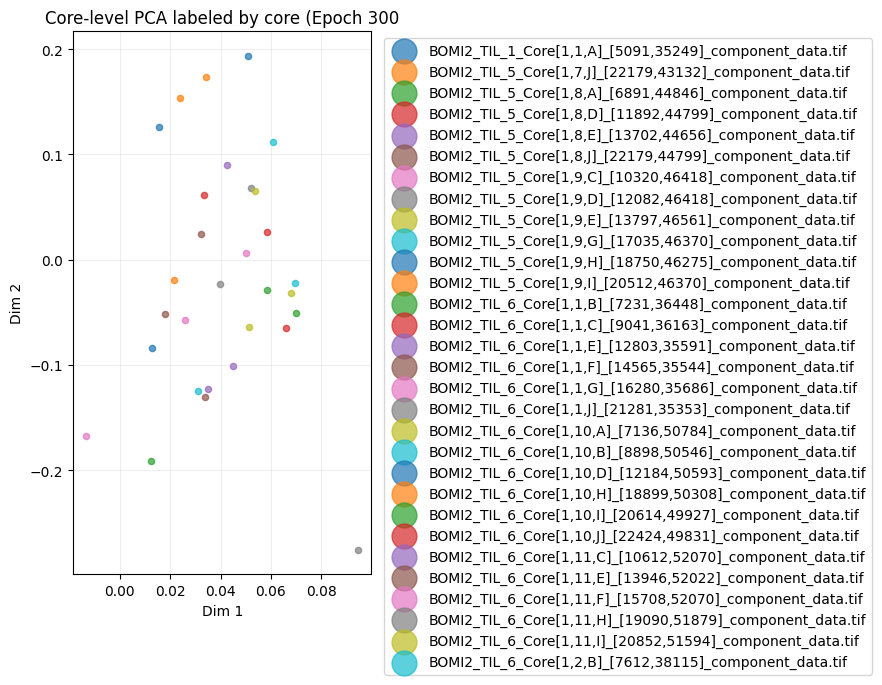

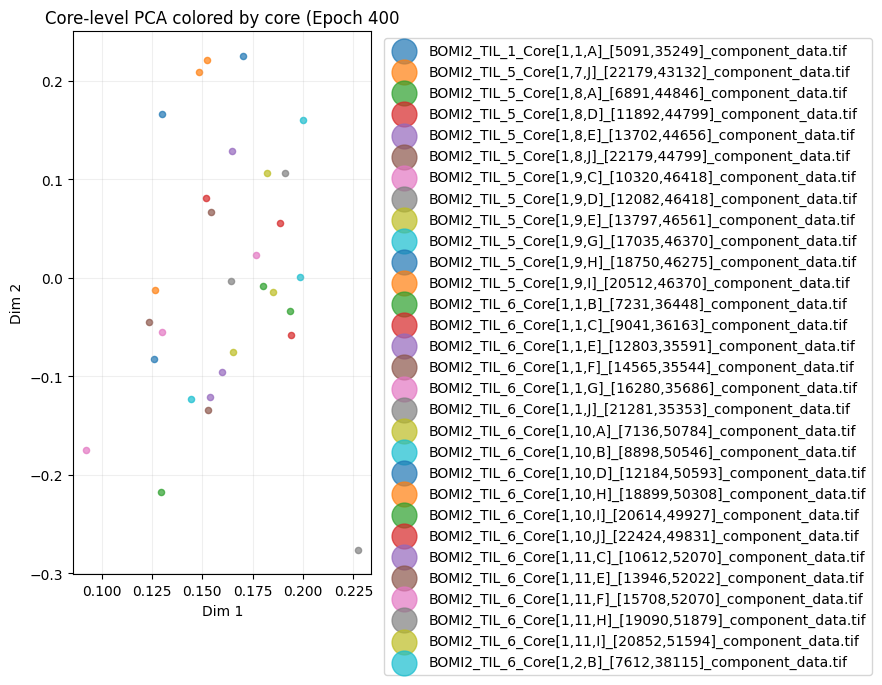

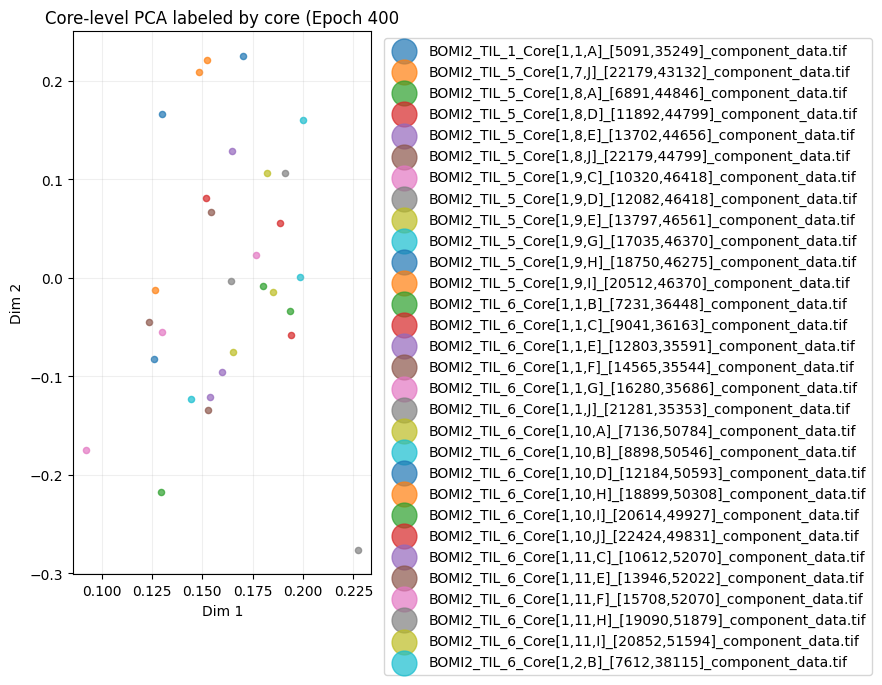

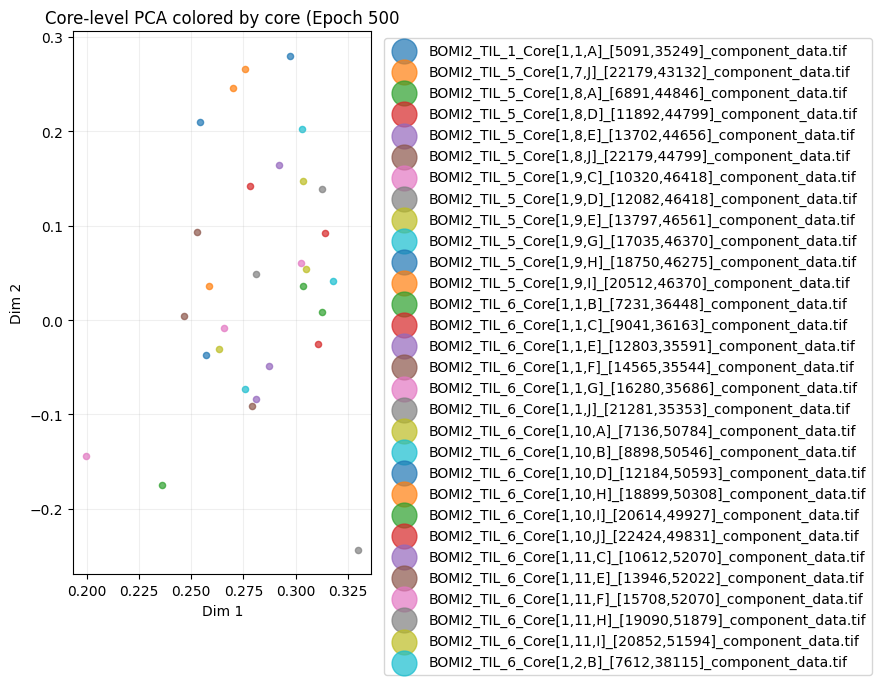

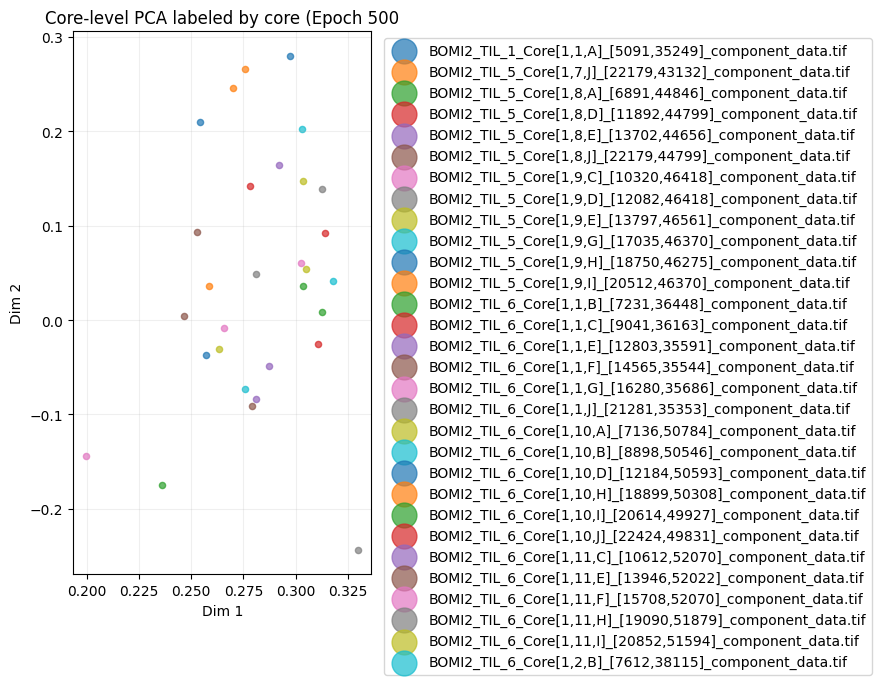

In [ ]:
# ---------------------------------------------------
# CORE LEVEL — colored plots
# ---------------------------------------------------
for ckpt in data.keys():
    plot_colored_subset(
        pca_core_meta[ckpt],
        color_col="image_name",
        title=f"Core-level PCA colored by core ({pretty_ckpt_name(ckpt)}",
        save_path=None,
        max_groups=30,
        s=20,
        alpha=0.7,
    )

    plot_colored_subset(
        pca_core_meta[ckpt],
        color_col="image_name",
        title=f"Core-level PCA labeled by core ({pretty_ckpt_name(ckpt)}",
        save_path=None,
        max_groups=30,
        s=20,
        alpha=0.7,
    )

## Core-level by patients

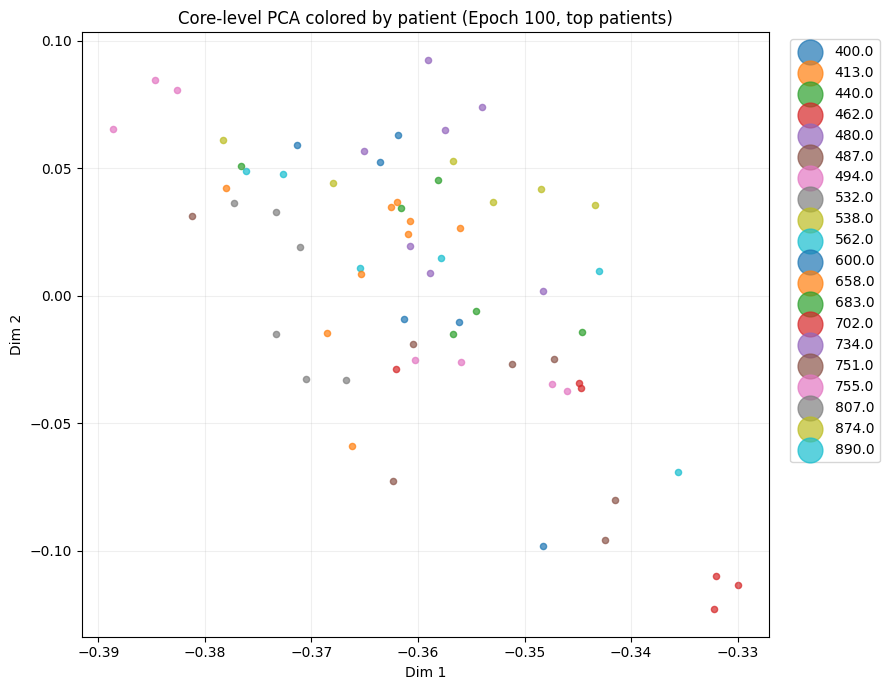

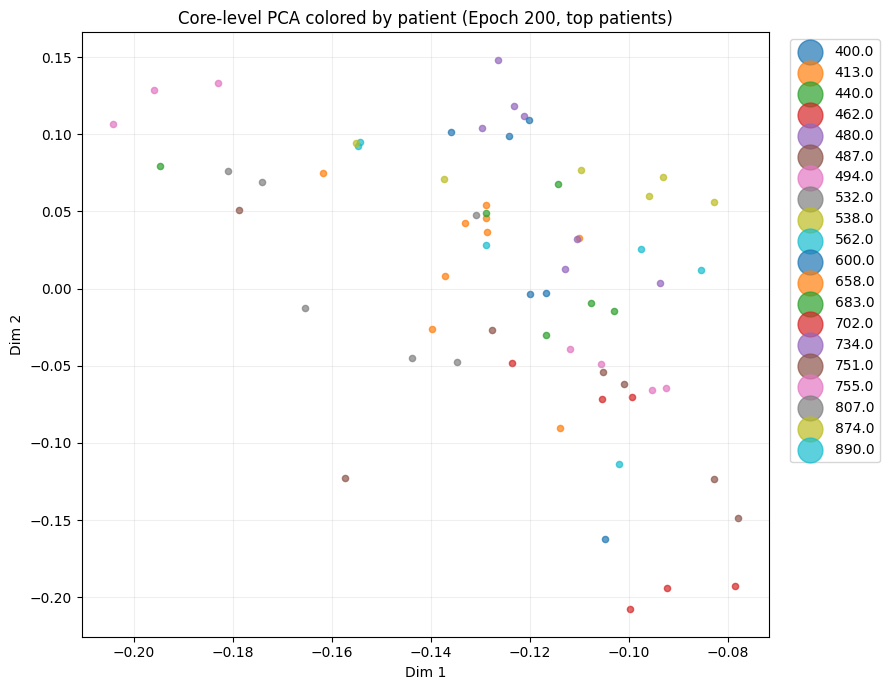

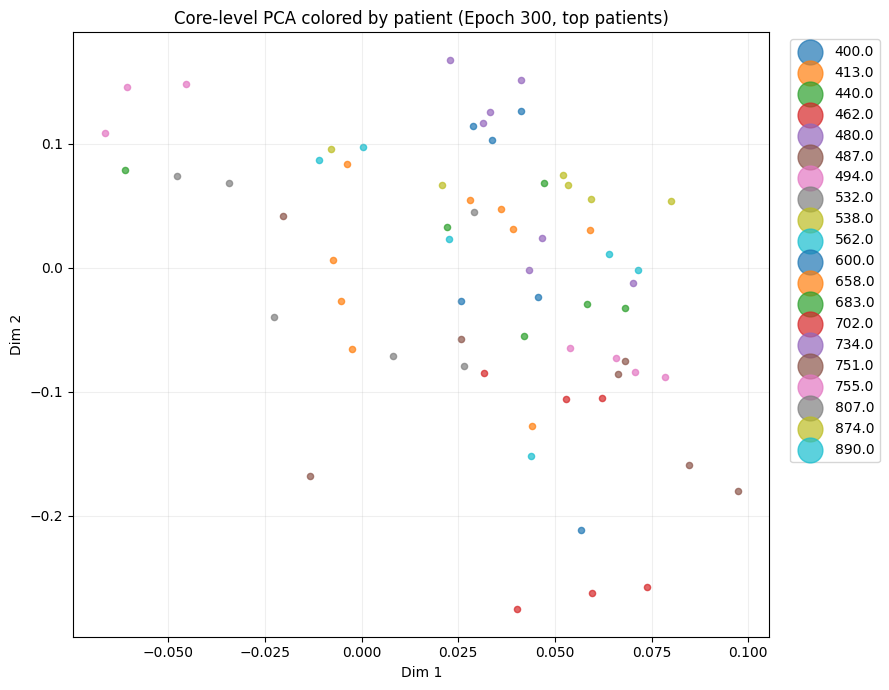

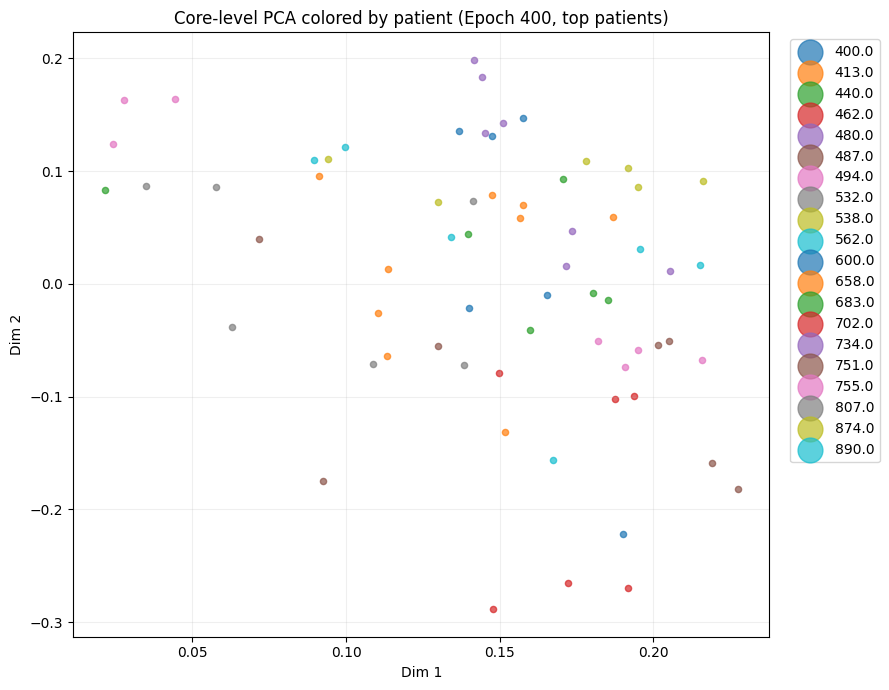

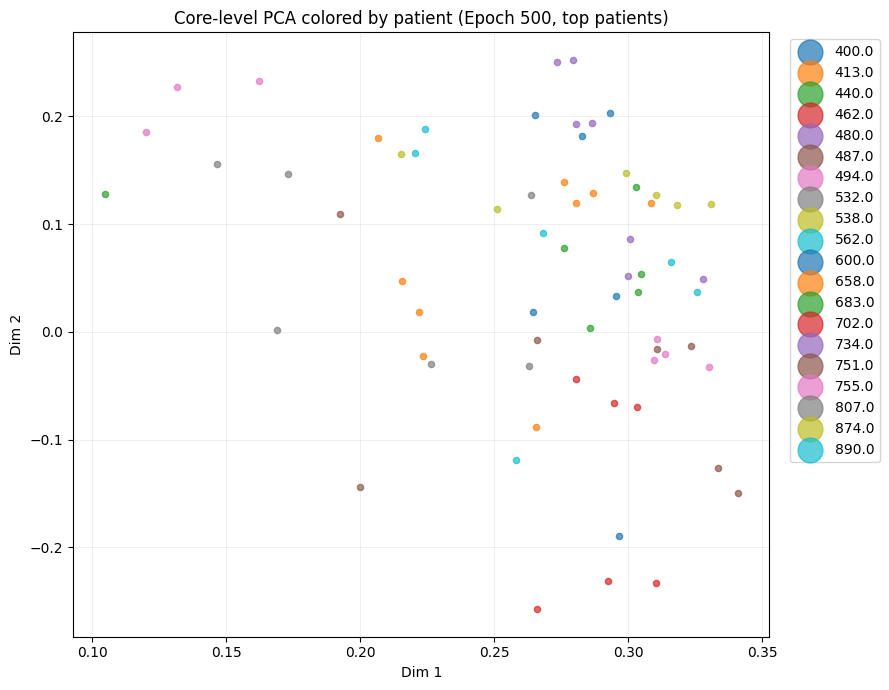

In [ ]:
# ---------------------------------------------------
# CORE LEVEL — colored by patient if available
# ---------------------------------------------------
for ckpt in data.keys():
    if "patient_id" in pca_core_meta[ckpt].columns:
        plot_colored_subset(
            pca_core_meta[ckpt],
            color_col="patient_id",
            title=f"Core-level PCA colored by patient ({pretty_ckpt_name(ckpt)}, top patients)",
            save_path=None,
            max_groups=20,
            s=20,
            alpha=0.7,
        )

In [ ]:
# Inspect one metadata table
first_ckpt = list(data.keys())[0]
data[first_ckpt]["meta"].head()

,raw_name,parsed_group_id,core_only,x,y,image_name,idx,image_path,sample_name,row,...,Histology,Age,Sex,Smoking,Stage (7th ed.),Performance status (WHO),Follow-up (days),Dead/Alive,time,event
0,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",BOMI2_TIL_1,"Core[1,1,A]",5091,35249,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",0,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_[1,A]",1.0,...,Squamous cell carcinoma,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0.0
1,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",BOMI2_TIL_1,"Core[1,1,A]",5091,35249,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",1,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_[1,A]",1.0,...,Squamous cell carcinoma,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0.0
2,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",BOMI2_TIL_1,"Core[1,1,A]",5091,35249,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",2,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_[1,A]",1.0,...,Squamous cell carcinoma,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0.0
3,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",BOMI2_TIL_1,"Core[1,1,A]",5091,35249,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",3,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_[1,A]",1.0,...,Squamous cell carcinoma,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0.0
4,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",BOMI2_TIL_1,"Core[1,1,A]",5091,35249,"BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component...",4,/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI...,"BOMI2_TIL_1_[1,A]",1.0,...,Squamous cell carcinoma,71.0,Female,Current smoker,Ib,1.0,4294.0,Alive,4294.0,0.0


In [ ]:
# Count patches per patient for one checkpoint
first_ckpt = list(data.keys())[0]
data[first_ckpt]["meta"]["patient_id"].value_counts().head(20)

patient_id
413.0    825
658.0    660
487.0    660
494.0    660
480.0    660
702.0    495
734.0    495
874.0    495
683.0    495
538.0    495
890.0    495
462.0    495
755.0    495
562.0    495
807.0    495
400.0    495
751.0    495
600.0    495
532.0    495
440.0    495
Name: count, dtype: int64

In [ ]:
# Count patches per core for one checkpoint
first_ckpt = list(data.keys())[0]
data[first_ckpt]["meta"]["image_name"].value_counts().head(20)

image_name
BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component_data.tif      165
BOMI2_TIL_6_Core[1,1,E]_[12803,35591]_component_data.tif     165
BOMI2_TIL_6_Core[1,11,I]_[20852,51594]_component_data.tif    165
BOMI2_TIL_6_Core[1,11,H]_[19090,51879]_component_data.tif    165
BOMI2_TIL_6_Core[1,11,F]_[15708,52070]_component_data.tif    165
BOMI2_TIL_6_Core[1,11,E]_[13946,52022]_component_data.tif    165
BOMI2_TIL_6_Core[1,11,C]_[10612,52070]_component_data.tif    165
BOMI2_TIL_6_Core[1,10,J]_[22424,49831]_component_data.tif    165
BOMI2_TIL_6_Core[1,10,I]_[20614,49927]_component_data.tif    165
BOMI2_TIL_6_Core[1,10,H]_[18899,50308]_component_data.tif    165
BOMI2_TIL_6_Core[1,10,D]_[12184,50593]_component_data.tif    165
BOMI2_TIL_6_Core[1,10,B]_[8898,50546]_component_data.tif     165
BOMI2_TIL_6_Core[1,10,A]_[7136,50784]_component_data.tif     165
BOMI2_TIL_6_Core[1,1,J]_[21281,35353]_component_data.tif     165
BOMI2_TIL_6_Core[1,1,G]_[16280,35686]_component_data.tif     165
BOMI2_TIL_6_Co

In [ ]:
import pandas as pd

csv_path = "/proj/berzelius-2025-315/users/x_dilwi/bomi2_image_level_with_survival.csv"
df = pd.read_csv(csv_path)


# 1. Count occurrences of every unique value in a column
counts = df['patient_id_raw'].value_counts()

# 2. Get only the total number of duplicate rows in that column
total_duplicates = df.duplicated(subset=['patient_id_raw']).sum()

print(f"Total duplicate entries: {total_duplicates}")
print(counts[counts > 1]) # Shows only values that appear more than once

Total duplicate entries: 244
patient_id_raw
Lung # 413    5
Lung # 658    4
Lung # 487    4
Lung # 494    4
Lung # 480    4
             ..
Lung # 851    2
Lung # 544    2
Lung # 690    2
Lung # 669    2
Lung # 682    2
Name: count, Length: 215, dtype: int64


In [ ]:
ckpt = list(data.keys())[-1]  # pick one
meta = data[ckpt]["meta"]

print("Total rows:", len(meta))
print("image_name NaNs:", meta["image_name"].isna().sum())
print("patient_id NaNs:", meta["patient_id"].isna().sum())

# show the problematic names
bad = meta[meta["image_name"].isna()]
bad[["raw_name", "patient_id", "image_name"]].head(20)

Total rows: 89430
image_name NaNs: 165
patient_id NaNs: 165


,raw_name,patient_id,image_name
76725,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76726,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76727,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76728,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76729,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76730,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76731,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76732,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76733,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
76734,"BOMI2_TIL_7_Core[1,5,D]_[11021,39539]_M2_compo...",NaN,None
